# Notebook 03 — Event-Conditioned Reliability Analysis
**Thesis Chapter 7** | **Input:** `data/2_events.csv` | **Output:** `data/3_results.csv`

---

## Purpose — three research questions

| RQ | Question | Section |
|----|---------|---------|
| RQ1 | What does reconstruction reveal about campaign-wide reliability? | §7.1 — global PDR, rolling time series, burst distribution |
| RQ2 | How does reliability vary across environmental and operational events? | §7.3–7.6 — event-conditioned PDR for all 8 events |
| RQ3 | Which conditions are most strongly associated with loss risk? | §7.7 — logistic regression, odds ratios |

## Filtered dataset
All event-conditioned analysis uses `df_link` — outage intervals excluded:
```python
df_link = df[~df['is_outage']].copy()
```
This ensures PDR variation reflects radio-channel conditions, not infrastructure downtime.


## 0 · Imports & Load

In [1]:
import pandas as pd
from pathlib import Path
import warnings
# TODO - TRY OUT TEMPORAL PLOTS ON THE LEFT, AND ON THE RIGHT WE HAVE THE BARS as they are, we see whether we have some trend of event against pdr
warnings.filterwarnings('ignore')

DATA_DIR = Path('../data')

df = pd.read_csv(DATA_DIR / '2_events.csv')
df['time'] = pd.to_datetime(df['time'], utc=True)
df = df.sort_values(['device_id', 'time']).reset_index(drop=True)

# filtered dataset — outage intervals excluded only
df_link = df[~df['is_outage']].copy().reset_index(drop=True)


EXPECTED_DEVICES = ['ED0', 'ED1', 'ED2', 'ED3', 'ED4', 'ED5']
assert sorted(df_link['device_id'].unique()) == EXPECTED_DEVICES, (
    f'Subset detected: {sorted(df_link["device_id"].unique())} — '
    f'rerun NB02 on the full dataset first.'
)
assert len(df) >= 2_600_000, f'Only {len(df):,} rows — full campaign required.'

print(f'Full dataset : {len(df):,} rows')
print(f'df_link      : {len(df_link):,} rows')
print(f'Excluded     : {len(df) - len(df_link):,} rows (outages)')
print(f'Devices      : {sorted(df_link["device_id"].unique())}')
print(f'Campaign     : {df["time"].min().date()} → {df["time"].max().date()}')

Full dataset : 2,634,930 rows
df_link      : 2,634,454 rows
Excluded     : 476 rows (outages)
Devices      : ['ED0', 'ED1', 'ED2', 'ED3', 'ED4', 'ED5']
Campaign     : 2024-10-01 → 2025-09-30


In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams.update(
    {
        'font.family': 'serif',
        'font.size': 12,
        'axes.titlesize': 13,
        'axes.labelsize': 13,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'legend.fontsize': 11,
        'figure.dpi': 150,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.grid': True,
        'grid.alpha': 0.3,
        'grid.linestyle': '--',
    }
)
C = {
    'blue': '#0077BB',
    'orange': '#EE7733',
    'green': '#009988',
    'red': '#CC3311',
    'purple': '#AA3377',
    'navy': '#004488',
    'grey': '#BBBBBB',
    'brown': '#882255',
    'teal': '#44AA99',
    'yellow': '#DDCC77',
}
DEVICE_COLORS = [C['blue'], C['orange'], C['green'], C['red'], C['purple'], C['navy']]
TOA_MS = {7: 71.9, 8: 133.6, 9: 246.8, 10: 452.6, 11: 987.1, 12: 1810.4}
FIG_DIR = Path('../figures/3')
FIG_DIR.mkdir(exist_ok=True)


def save_fig(fig, name):
    # fig.savefig(FIG_DIR / f'{name}.pdf')
    fig.savefig(FIG_DIR / f'{name}.png')
    print(f'  Saved: figures/3/{name}')
    plt.show()


def pdr_grp(grp):
    rx = len(grp)
    lost = int(grp['tx_loss'].sum())
    return rx / (rx + lost) * 100 if (rx + lost) > 0 else 0


def burst_rate_grp(grp):
    return (grp['tx_loss'] >= 3).mean() * 100


print('Style ready.')


# ---------------------------------------------------------------------------
# Two-panel event figures
#
# Left  : PDR against the continuous variable underlying the event, binned.
#         This exposes the gradient that the locked tiers discretize.
# Right : PDR by locked tier, the contrast reported in the thesis.
# ---------------------------------------------------------------------------

PDR_LABEL = 'PDR$_{\\mathrm{link}}$ (%)'


def event_panels(figsize=(11.2, 4.2), ratios=(1.25, 1.0)):
    """Side-by-side axes for one event: profile on the left, tiers on the right."""
    fig, (ax_l, ax_r) = plt.subplots(
        1, 2, figsize=figsize, gridspec_kw={'width_ratios': list(ratios)}
    )
    return fig, ax_l, ax_r

# todo Adjust data points... CAN WE MAKE THIS MORE DYNAMICALLY THIS?
def pdr_profile(ax, data, col, n_bins=100, log_x=False, boundaries=None,
                xlabel=None, color=None, min_n=500):
    """PDR as a function of a continuous event variable, computed per bin."""
    s = pd.to_numeric(data[col], errors='coerce')
    keep = s.notna()
    s, d = s[keep], data[keep]

    lo, hi = float(s.quantile(0.001)), float(s.quantile(0.999))
    if log_x:
        pos = s[s > 0]
        lo = max(lo, float(pos.min())) if len(pos) else 1e-3
        edges = np.logspace(np.log10(lo), np.log10(max(hi, lo * 10)), n_bins + 1)
    else:
        if hi <= lo:
            hi = lo + 1.0
        edges = np.linspace(lo, hi, n_bins + 1)

    idx = np.digitize(s.to_numpy(), edges) - 1
    xs, ys, ns = [], [], []
    for b in range(n_bins):
        g = d[idx == b]
        if len(g) < min_n:
            continue
        centre = (np.sqrt(edges[b] * edges[b + 1]) if log_x
                  else (edges[b] + edges[b + 1]) / 2)
        xs.append(centre)
        ys.append(pdr_grp(g))
        ns.append(len(g))

    ax.plot(xs, ys, 'o-', color=color or C['navy'], lw=2, ms=5, zorder=3)
    for b in (boundaries or []):
        ax.axvline(b, color=C['grey'], ls='--', lw=1.3, zorder=1)
    if log_x:
        ax.set_xscale('log')
    ax.set_xlabel(xlabel or col, fontsize=13, fontweight='bold')
    ax.set_ylabel(PDR_LABEL, fontsize=13, fontweight='bold')
    ax.tick_params(labelsize=11)
    return xs, ys, ns


def tier_bars(ax, values, labels, colors, width=0.55, fontsize=11):
    """PDR by locked tier, matching the bar style used throughout the thesis."""
    x = np.arange(len(labels)) * 0.75
    bars = ax.bar(x, values, width, color=colors, alpha=0.88, edgecolor='white')

    span = max(values) - min(values)
    pad = max(span * 0.05, 0.15)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + pad, f'{v:.2f}%',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=fontsize, fontweight='bold')
    ax.margins(x=0.06)
    ax.set_ylabel(PDR_LABEL, fontsize=13, fontweight='bold')
    ax.tick_params(axis='y', labelsize=11)
    ax.set_ylim(max(0, min(values) - span * 0.6 - 1),
                min(101, max(values) + span * 0.4 + pad * 4))
    return bars


Style ready.


## 1 · Statistical Framework  *(§5.5.1)*

All event-conditioned comparisons use the same pipeline:

1. **PDR** — computed per event group from `tx_loss`, pooled across the group
2. **Synchronised 7-day block bootstrap** — the campaign is split into non-overlapping weekly blocks; blocks are resampled with replacement (keeping all six devices together within each sampled block), and PDR is recalculated for both groups on every resample
3. **95% confidence interval** — the 2.5th/97.5th percentiles of 2,000 bootstrap replicates of ΔPDR
4. **Decision rule** — a difference is *statistically supported* when the 95% CI excludes zero

This function is called for every binary comparison in sections 3–8.

In [3]:
def pdr_compare(
        df_in,
        event_col,
        group1_label,
        group0_label=None,
        n_boot=10000,
        block_days=1,
        random_state=42,
):
    """
    Compare PDR between two event groups using a synchronised time-block
    bootstrap. Returns PDR for each group, the observed difference, and a
    95% confidence interval for that difference.

    The campaign is split into non-overlapping `block_days`-day blocks.
    Every bootstrap resample draws whole blocks with replacement, keeping
    all six devices' data for a given block together, so within-device
    bursts and cross-device shared events (outages, occupancy swings) are
    preserved rather than broken apart. This directly answers the
    question "is this PDR difference statistically supported", not a
    proxy question about rank distributions.
    """
    active_mask = df_in[event_col].eq(group1_label)
    if group0_label is None:
        reference_mask = (~active_mask) & df_in[event_col].notna()
        reference_name = f'not {group1_label}'
    else:
        reference_mask = df_in[event_col].eq(group0_label)
        reference_name = group0_label

    if (active_mask & reference_mask).any():
        raise ValueError('Active and reference groups overlap.')

    n_active_raw = int(active_mask.sum())
    n_reference_raw = int(reference_mask.sum())
    if n_active_raw == 0 or n_reference_raw == 0:
        raise ValueError(
            f'Empty comparison group for {event_col}: '
            f'active={n_active_raw}, reference={n_reference_raw}.'
        )

    # One shared block index spanning the full campaign
    campaign_start = df_in['time'].min().floor('D')
    block_ids_full = (
            (df_in['time'] - campaign_start).dt.total_seconds() // (block_days * 24 * 60 * 60)
    ).astype(int)
    all_blocks = np.sort(block_ids_full.unique())

    selected_mask = active_mask | reference_mask
    work = df_in.loc[selected_mask, ['time', 'tx_loss']].copy()
    work['block_id'] = block_ids_full.loc[work.index].to_numpy()

    active_sel = active_mask.loc[work.index].astype(np.int8).to_numpy()
    reference_sel = reference_mask.loc[work.index].astype(np.int8).to_numpy()
    losses = pd.to_numeric(work['tx_loss'], errors='coerce').fillna(0).to_numpy(dtype=float)

    work['rx_active'] = active_sel
    work['loss_active'] = losses * active_sel
    work['rx_reference'] = reference_sel
    work['loss_reference'] = losses * reference_sel

    count_cols = ['rx_active', 'loss_active', 'rx_reference', 'loss_reference']
    block_totals = (
        work.groupby('block_id', sort=True)[count_cols]
        .sum()
        .reindex(all_blocks, fill_value=0.0)
    )

    observed = block_totals.sum(axis=0)
    rx_active = int(observed['rx_active'])
    loss_active = int(round(observed['loss_active']))
    rx_reference = int(observed['rx_reference'])
    loss_reference = int(round(observed['loss_reference']))

    def _pdr(rx, lost):
        denom = rx + lost
        return 100.0 * rx / denom if denom > 0 else np.nan

    pdr_active = _pdr(rx_active, loss_active)
    pdr_reference = _pdr(rx_reference, loss_reference)
    delta_observed = pdr_active - pdr_reference

    values = block_totals.to_numpy(dtype=float)
    n_blocks = len(values)
    if n_blocks < 8:
        raise ValueError(
            f'Only {n_blocks} time blocks available for {event_col}. '
            'Use a shorter block length.'
        )

    rng = np.random.default_rng(random_state)
    sampled_idx = rng.integers(0, n_blocks, size=(n_boot, n_blocks))
    sampled_totals = values[sampled_idx].sum(axis=1)

    rx_a, loss_a = sampled_totals[:, 0], sampled_totals[:, 1]
    rx_r, loss_r = sampled_totals[:, 2], sampled_totals[:, 3]
    denom_a, denom_r = rx_a + loss_a, rx_r + loss_r
    valid = (denom_a > 0) & (denom_r > 0)

    boot_deltas = 100.0 * rx_a[valid] / denom_a[valid] - 100.0 * rx_r[valid] / denom_r[valid]

    if len(boot_deltas) < max(100, int(0.5 * n_boot)):
        raise RuntimeError(
            f'Only {len(boot_deltas)} of {n_boot} bootstrap resamples for '
            f'{event_col} contained both comparison groups.'
        )

    ci_low, ci_high = np.percentile(boot_deltas, [2.5, 97.5])
    supported = bool((ci_high < 0) or (ci_low > 0))
    inference = (
        'lower PDR' if ci_high < 0 else ('higher PDR' if ci_low > 0 else 'inconclusive')
    )

    return {
        'group1': group1_label,
        'n1': rx_active,
        'pdr1': pdr_active,
        'group0': reference_name,
        'n0': rx_reference,
        'pdr0': pdr_reference,
        'diff_pp': delta_observed,
        'ci_low_pp': float(ci_low),
        'ci_high_pp': float(ci_high),
        'statistically_supported': supported,
        'inference': inference,
        'n_blocks': n_blocks,
        'block_days': block_days,
        'n_boot': int(len(boot_deltas)),
    }


def print_comparison(result, title=''):
    sig = (
        '\u2713 statistically supported'
        if result['statistically_supported']
        else '\u2717 inconclusive (CI includes 0)'
    )
    print(f"  {title}")
    print(f"    {str(result['group1']):>20}: {result['pdr1']:.2f}%  (n={result['n1']:,})")
    print(f"    {str(result['group0']):>20}: {result['pdr0']:.2f}%  (n={result['n0']:,})")
    print(f"    Difference        : {result['diff_pp']:+.2f} pp")
    print(
        f"    95% block CI      : [{result['ci_low_pp']:+.2f}, {result['ci_high_pp']:+.2f}] pp"
    )
    print(f"    Inference         : {result['inference']}  {sig}")
    print(
        f"    Bootstrap design  : {result['n_boot']:,} resamples of {result['n_blocks']} x {result['block_days']}-day blocks"
    )
    print()


print('Statistical framework ready.')
print('Primary design: synchronised 1-day block bootstrap, 10,000 resamples.')
print('Sensitivity check: 7-day blocks (run separately below).')

Statistical framework ready.
Primary design: synchronised 1-day block bootstrap, 10,000 resamples.
Sensitivity check: 7-day blocks (run separately below).


## 2 · CO₂ Tier  *(§7.4 — RQ2)*

**Hypothesis:** Higher CO₂ → more people → more RF interference → lower PDR.

Event: E1 (CO₂ tier)

In [4]:
print('=' * 60)
print('CO2 TIER (§7.4)')
print('=' * 60)

occupancy_results = {}

# E1: CO2 tier — three-way comparison
print('\nE1: CO2 Tier PDR')
co2_pdrs = {}
for tier in ['background', 'moderate', 'high']:
    g = df_link[df_link['e1_co2_tier'] == tier]
    rx = len(g)
    lost = int(g['tx_loss'].sum())
    pdr = rx / (rx + lost) * 100
    co2_pdrs[tier] = pdr
    print(f'    {tier:<12}: {pdr:.2f}%  (n={rx:,})')

# key comparison: high vs background
print('\nE1: High vs Background CO2 (key comparison)')
r = pdr_compare(df_link, 'e1_co2_tier', 'high', 'background')
print_comparison(r, 'High CO2 vs Background')
occupancy_results['E1_high_vs_bg'] = r

# moderate vs background
r = pdr_compare(df_link, 'e1_co2_tier', 'moderate', 'background')
print_comparison(r, 'Moderate CO2 vs Background')
occupancy_results['E1_mod_vs_bg'] = r

CO2 TIER (§7.4)

E1: CO2 Tier PDR
    background  : 98.32%  (n=1,670,651)
    moderate    : 97.59%  (n=742,541)
    high        : 95.07%  (n=221,262)

E1: High vs Background CO2 (key comparison)
  High CO2 vs Background
                    high: 95.07%  (n=221,262)
              background: 98.32%  (n=1,670,651)
    Difference        : -3.25 pp
    95% block CI      : [-3.90, -2.62] pp
    Inference         : lower PDR  ✓ statistically supported
    Bootstrap design  : 10,000 resamples of 350 x 1-day blocks

  Moderate CO2 vs Background
                moderate: 97.59%  (n=742,541)
              background: 98.32%  (n=1,670,651)
    Difference        : -0.74 pp
    95% block CI      : [-1.03, -0.47] pp
    Inference         : lower PDR  ✓ statistically supported
    Bootstrap design  : 10,000 resamples of 350 x 1-day blocks



  Saved: figures/3/05_03_a_co2_tier_pdr


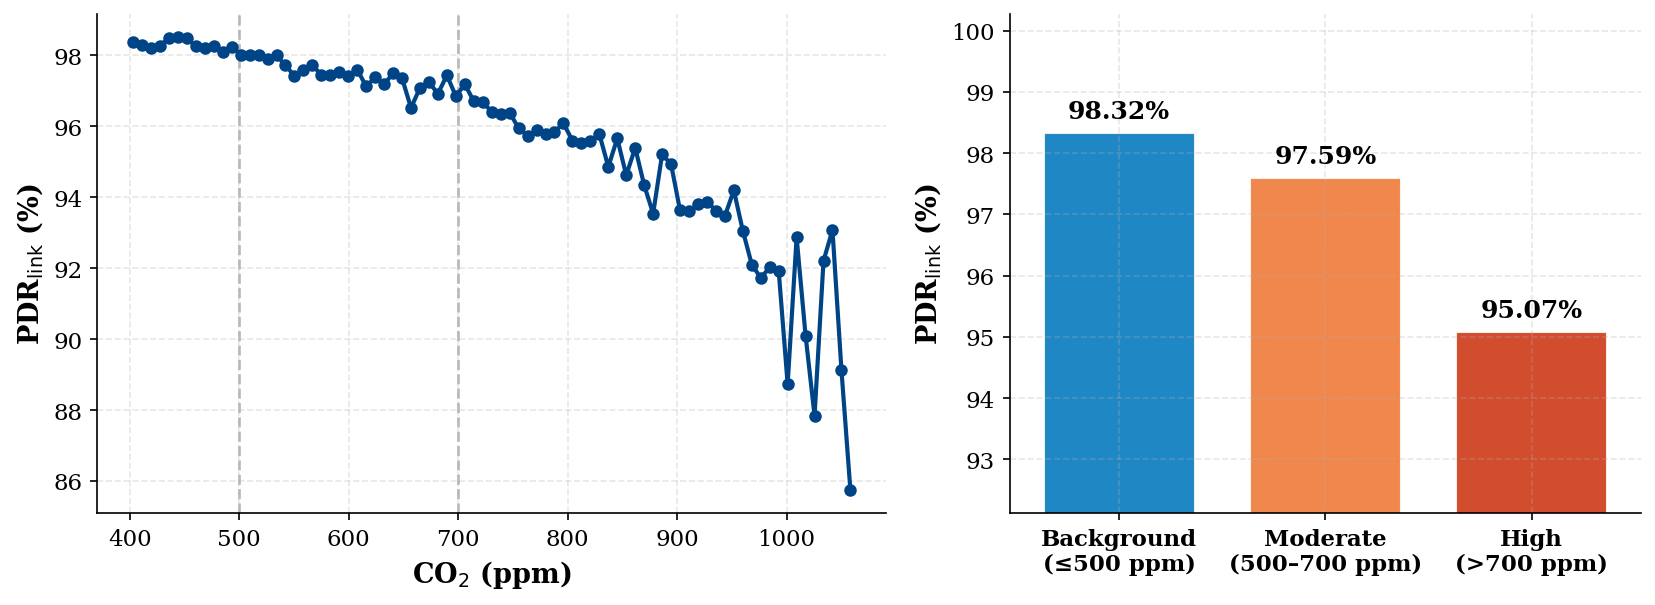

In [5]:
# Fig 05-03-a — CO2 Tier PDR (E1)
tiers    = ['background', 'moderate', 'high']
xlabs_e1 = ['Background\n(\u2264500 ppm)', 'Moderate\n(500\u2013700 ppm)', 'High\n(>700 ppm)']
pdrs_e1  = [pdr_grp(df_link[df_link['e1_co2_tier'] == t]) for t in tiers]
colors_e1 = [C['blue'], C['orange'], C['red']]

fig, axL, axR = event_panels()
pdr_profile(axL, df_link, 'co2', boundaries=[500, 700],
            xlabel='CO$_2$ (ppm)', color=C['navy'])
tier_bars(axR, pdrs_e1, xlabs_e1, colors_e1)

fig.tight_layout()
save_fig(fig, '05_03_a_co2_tier_pdr')


## 3 · ΔCO₂  *(§7.4 — RQ2)*

Event: E2 (CO₂ rising)

E2 shows by far the largest reliability gap of any event and is treated as an
activity-transition signal, not a confirmed causal mechanism — see the
leakage-concern note printed below before this result is reported as a
genuine occupancy-transition effect.

In [6]:
print('=' * 60)
print('DELTA CO2 — RAPID CO2 CHANGE (§7.4)')
print('=' * 60)

# E2: ΔCO₂ rapid change
print('E2: ΔCO₂ Transition vs Stable')
r = pdr_compare(df_link, 'e2_co2_rising', 1, 0)
print_comparison(r, 'ΔCO₂ transition (1) vs stable (0)')
occupancy_results['E2_delta_co2'] = r

print('''
E2 shows by far the largest reliability gap in the taxonomy. This is treated as an
activity-transition SIGNAL, not a confirmed causal mechanism -- the event is defined as
CO2.diff() > 15ppm between consecutive RECEIVED packets, not consecutive scheduled 60s
samples. A long packet-loss gap mechanically gives CO2 more time to drift past the 15ppm
threshold in the SAME interval where tx_loss is elevated, which can inflate this
association independently of any real occupancy effect. This should be re-checked (e.g.
against scheduled 60s samples rather than received-packet gaps) before E2 is reported as
evidence of a genuine occupancy-transition effect rather than a definitional artifact.
''')

DELTA CO2 — RAPID CO2 CHANGE (§7.4)
E2: ΔCO₂ Transition vs Stable


KeyError: 'e2_co2_rising'

  Saved: figures/3/05_03_b_co2_rising_pdr


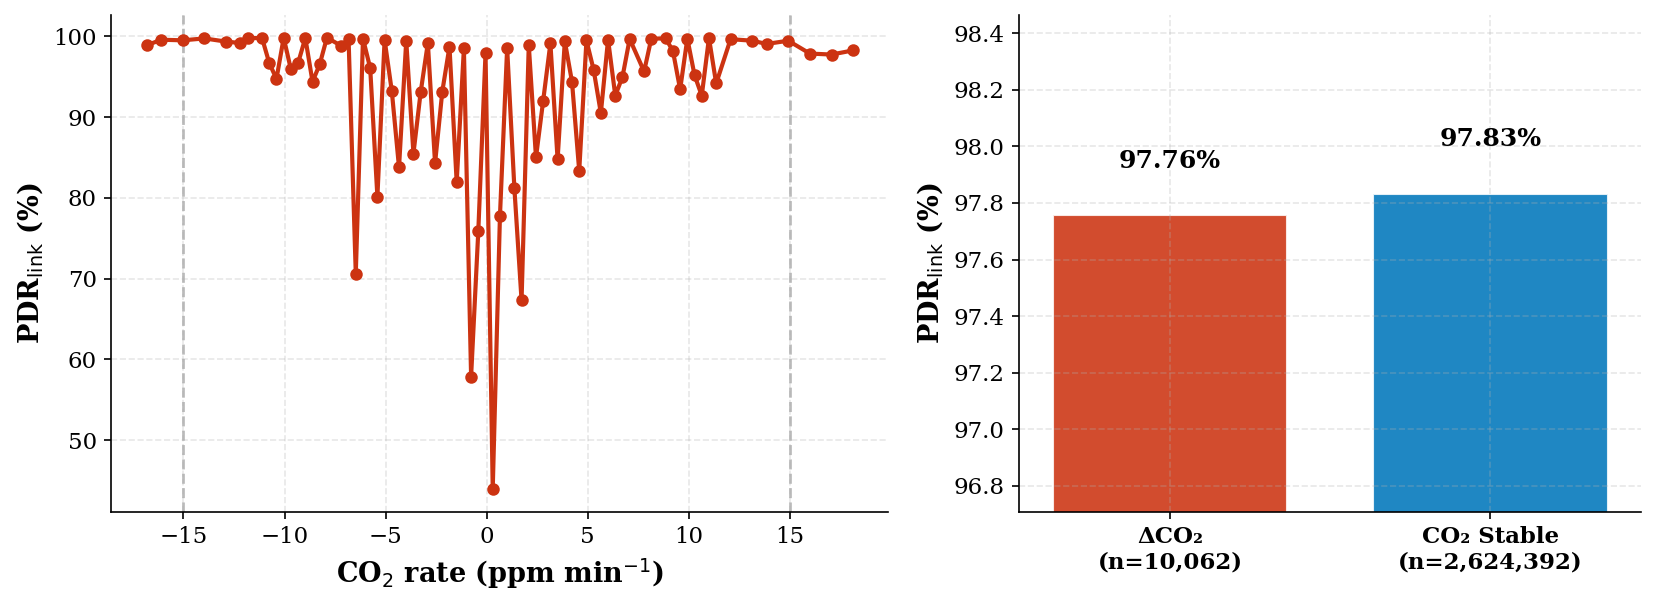

In [7]:
# Fig 05-03-b — ΔCO₂ Rapid Change vs Stable PDR (E2)
g1, g0 = df_link[df_link['e2_co2_rising'] == 1], df_link[df_link['e2_co2_rising'] == 0]
pdrs_e2 = [pdr_grp(g1), pdr_grp(g0)]
xlabs_e2 = [f'\u0394CO\u2082\n(n={len(g1):,})', f'CO\u2082 Stable\n(n={len(g0):,})']

# Left panel: PDR vs gap-corrected CO₂ rate from NB02
# Uses co2_rate_ppm_per_min (|Δco2/Δt| in ppm/min, normalised to actual
# elapsed seconds). Boundaries at ±15 ppm/min mark the E2 threshold.
fig, axL, axR = event_panels()
pdr_profile(axL, df_link.dropna(subset=['co2_rate_ppm_per_min']),
            'co2_rate_ppm_per_min', boundaries=[-15, 15],
            xlabel='CO$_2$ rate (ppm min$^{-1}$)', color=C['red'])
tier_bars(axR, pdrs_e2, xlabs_e2, [C['red'], C['blue']])

fig.tight_layout()
save_fig(fig, '05_03_b_co2_rising_pdr')

# TODO, SHOULD BE AROUND 80 AT CO2 RISING?


## 4 · Office Hours  *(§7.3 — RQ2)*

**Hypothesis:** Office hours show lower PDR due to higher human activity  
and increased RF interference from electronic devices.

Event: E3 (office hours)

In [8]:
print('=' * 60)
print('TEMPORAL EVENTS (E3)')
print('=' * 60)

temporal_results = {}

# E3: office hours binary
print('\nE3: Office Hours vs Off-Peak')
r = pdr_compare(df_link, 'e3_office_hours', 1, 0)
print_comparison(r, 'Office hours (1) vs off-peak (0)')
temporal_results['E3_office'] = r

TEMPORAL EVENTS (E3)

E3: Office Hours vs Off-Peak
  Office hours (1) vs off-peak (0)
                       1: 97.03%  (n=768,518)
                       0: 98.17%  (n=1,865,936)
    Difference        : -1.13 pp
    95% block CI      : [-1.44, -0.84] pp
    Inference         : lower PDR  ✓ statistically supported
    Bootstrap design  : 10,000 resamples of 350 x 1-day blocks



  Saved: figures/3/05_03_c_temporal_pdr


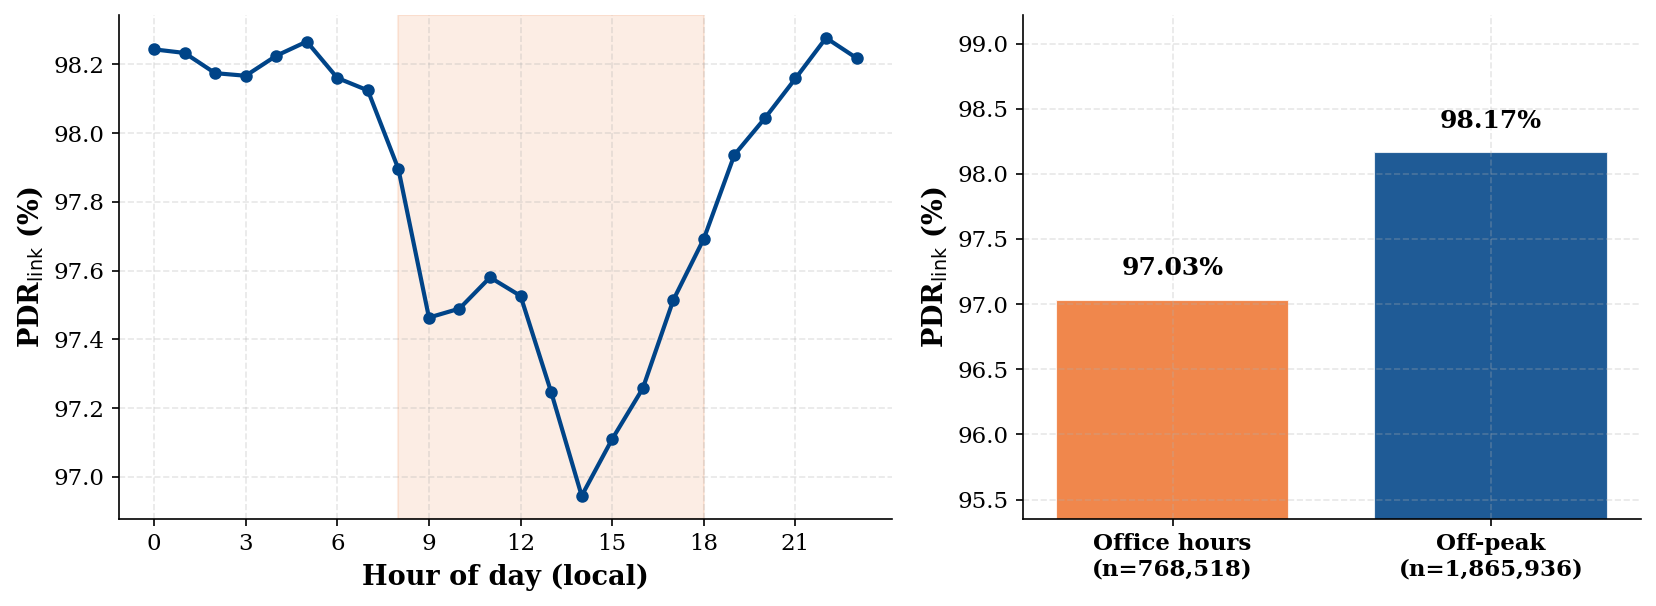

In [9]:
# Fig 05-03-c — Temporal Event PDR (E3)
g1, g0 = df_link[df_link['e3_office_hours'] == 1], df_link[df_link['e3_office_hours'] == 0]
pdrs_e3 = [pdr_grp(g1), pdr_grp(g0)]
xlabs_e3 = [f'Office hours\n(n={len(g1):,})', f'Off-peak\n(n={len(g0):,})']

# diurnal profile: PDR by local hour of day.
# 2_events.csv does not carry an 'hour' column (NB02 drops it before saving),
# so it is rebuilt here from 'time' using the same Europe/Berlin conversion
# NB02 uses for E3, keeping the two consistent.
_local_hour = df_link['time'].dt.tz_convert('Europe/Berlin').dt.hour
hours = list(range(24))
hourly = [pdr_grp(df_link[_local_hour == h]) for h in hours]

fig, axL, axR = event_panels()
axL.axvspan(8, 18, color=C['orange'], alpha=0.13, zorder=0)
axL.plot(hours, hourly, 'o-', color=C['navy'], lw=2, ms=5, zorder=3)
axL.set_xlabel('Hour of day (local)', fontsize=13, fontweight='bold')
axL.set_ylabel(PDR_LABEL, fontsize=13, fontweight='bold')
axL.set_xticks(range(0, 24, 3))
axL.tick_params(labelsize=11)
tier_bars(axR, pdrs_e3, xlabs_e3, [C['orange'], C['navy']])

fig.tight_layout()
save_fig(fig, '05_03_c_temporal_pdr')


## 5 · PM2.5 Tier  *(§7.5.1 — RQ2)*

Event: E4 (PM2.5 tier)

In [10]:
print('=' * 60)
print('AIR QUALITY EVENTS — PM2.5 (§7.5.1)')
print('=' * 60)

air_quality_results = {}

# E4: PM2.5 tier
print('\nE4: PM2.5 Absolute Tier')
for tier in ['clean', 'moderate', 'elevated']:
    g = df_link[df_link['e4_pm25_tier'] == tier]
    if len(g) > 0:
        rx = len(g)
        lost = int(g['tx_loss'].sum())
        pdr = rx / (rx + lost) * 100
        print(f'    {tier:<10}: {pdr:.2f}%  (n={rx:,})')

print('\nE4: Elevated vs Clean (key comparison)')
r = pdr_compare(df_link, 'e4_pm25_tier', 'elevated', 'clean')
print_comparison(r, 'Elevated vs Clean PM2.5')
air_quality_results['E4_elevated_vs_clean'] = r

AIR QUALITY EVENTS — PM2.5 (§7.5.1)

E4: PM2.5 Absolute Tier
    clean     : 98.10%  (n=2,412,352)
    moderate  : 95.74%  (n=215,152)
    elevated  : 78.09%  (n=6,950)

E4: Elevated vs Clean (key comparison)
  Elevated vs Clean PM2.5
                elevated: 78.09%  (n=6,950)
                   clean: 98.10%  (n=2,412,352)
    Difference        : -20.01 pp
    95% block CI      : [-27.90, -15.25] pp
    Inference         : lower PDR  ✓ statistically supported
    Bootstrap design  : 10,000 resamples of 350 x 1-day blocks



  Saved: figures/3/05_03_d_pm25_pdr


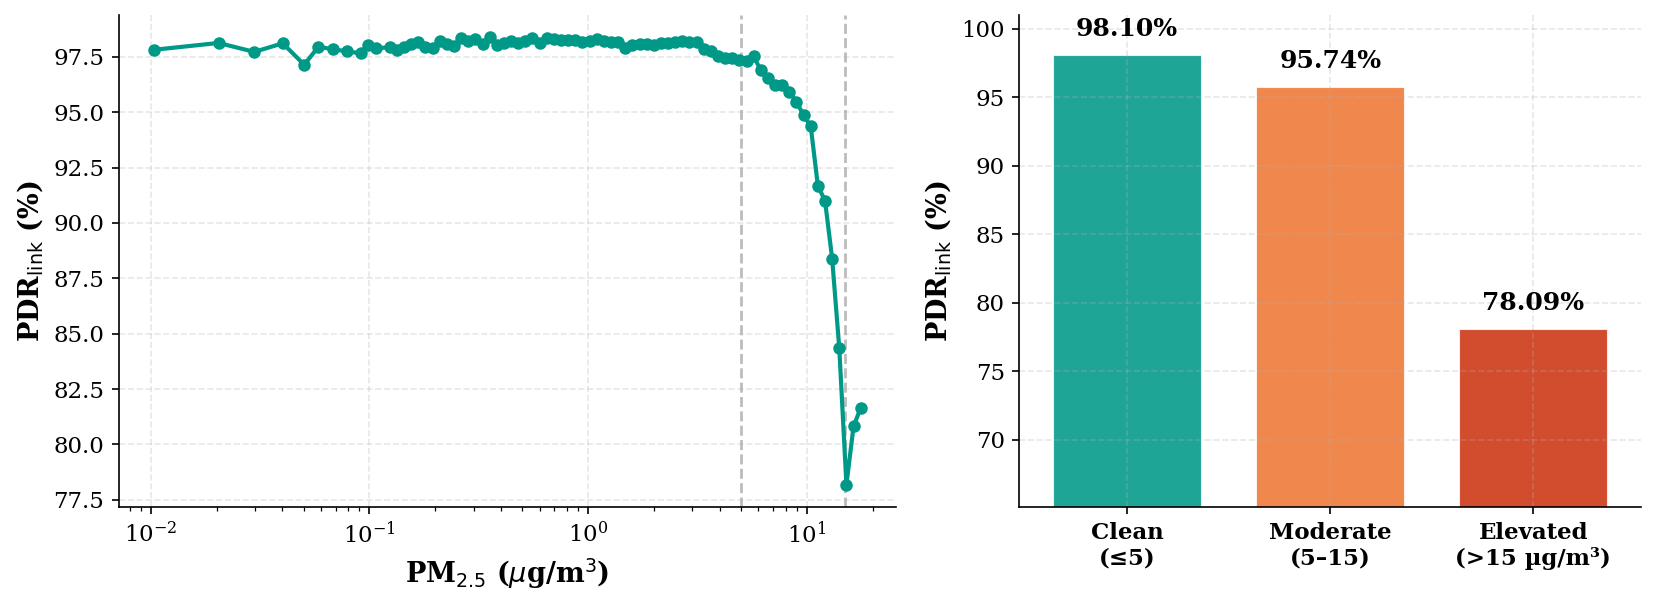

In [11]:
# Fig 05-03-d — PM2.5 Event PDR (E4)
pm_tiers = ['clean', 'moderate', 'elevated']
pm_labs  = ['Clean\n(\u22645)', 'Moderate\n(5\u201315)', 'Elevated\n(>15 \u00b5g/m\u00b3)']
pm_pdrs  = [pdr_grp(df_link[df_link['e4_pm25_tier'] == t]) for t in pm_tiers]

fig, axL, axR = event_panels()
pdr_profile(axL, df_link, 'pm25', log_x=True, boundaries=[5, 15],
            xlabel='PM$_{2.5}$ ($\\mu$g/m$^3$)', color=C['green'], min_n=200)
tier_bars(axR, pm_pdrs, pm_labs, [C['green'], C['orange'], C['red']])

fig.tight_layout()
save_fig(fig, '05_03_d_pm25_pdr')
# TODO Y AXIS TO HAVE REAL NUMBERS AS LABELS, TO EASE THE INTERPRETATION?


## 6 · Temperature Tier  *(§7.5.2 — RQ2)*

Event: E5 (temperature tier)

In [12]:
print('=' * 60)
print('TEMPERATURE TIER (§7.5.2)')
print('=' * 60)

atm_results = {}

# E5: temperature tier
print('\nE5: Temperature Tier PDR')
for tier in ['cool', 'moderate', 'warm']:
    g = df_link[df_link['e5_temp_tier'] == tier]
    if len(g) > 0:
        rx = len(g)
        lost = int(g['tx_loss'].sum())
        pdr = rx / (rx + lost) * 100
        print(f'    {tier:<10}: {pdr:.2f}%  (n={rx:,})')

print('\nE5: Warm vs Cool (key comparison)')
r = pdr_compare(df_link, 'e5_temp_tier', 'warm', 'cool')
print_comparison(r, 'Warm vs Cool')
atm_results['E5_warm_vs_cool'] = r

TEMPERATURE TIER (§7.5.2)

E5: Temperature Tier PDR
    cool      : 97.30%  (n=876,801)
    moderate  : 97.99%  (n=886,499)
    warm      : 98.21%  (n=871,154)

E5: Warm vs Cool (key comparison)
  Warm vs Cool
                    warm: 98.21%  (n=871,154)
                    cool: 97.30%  (n=876,801)
    Difference        : +0.91 pp
    95% block CI      : [+0.49, +1.32] pp
    Inference         : higher PDR  ✓ statistically supported
    Bootstrap design  : 10,000 resamples of 350 x 1-day blocks



  Saved: figures/3/05_03_e_temperature_pdr


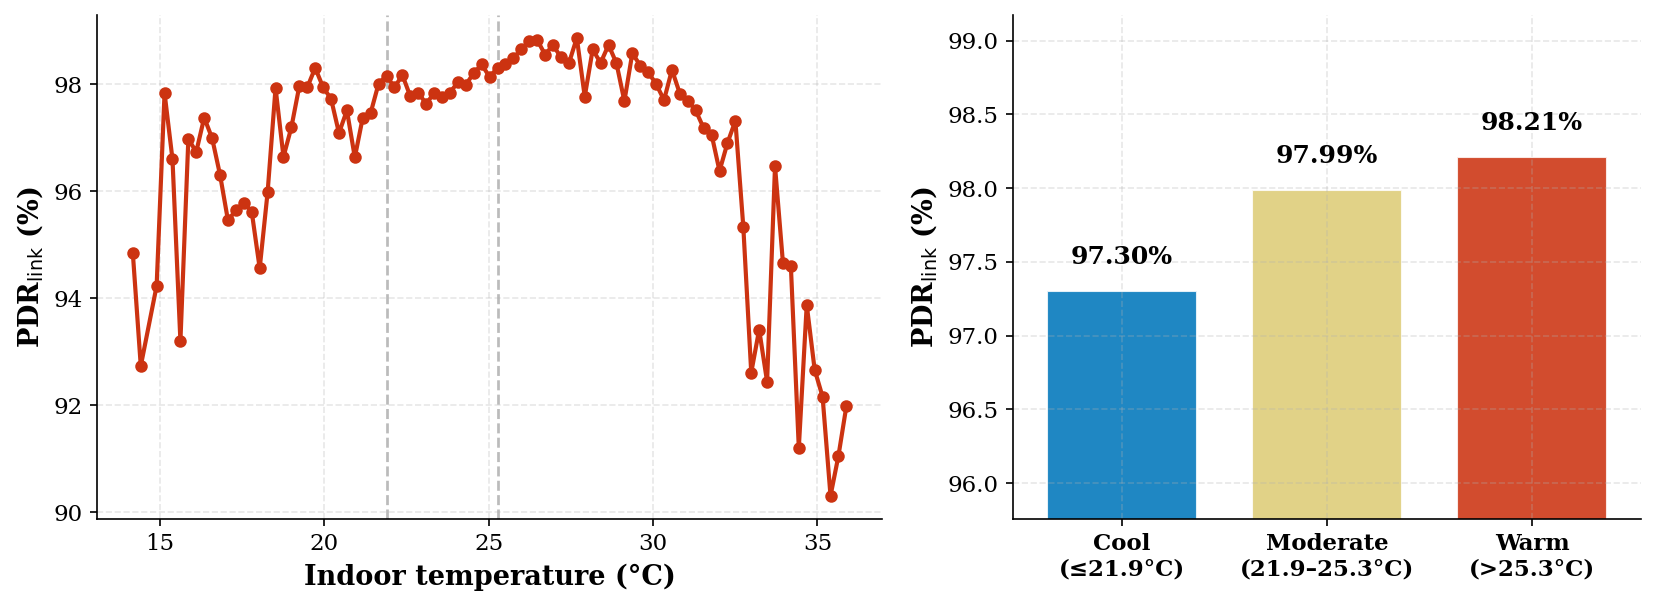

In [13]:
# Fig 05-03-e — Temperature Tier PDR (E5)
tt      = ['cool', 'moderate', 'warm']
tt_labs = ['Cool\n(\u226421.9\u00b0C)', 'Moderate\n(21.9\u201325.3\u00b0C)', 'Warm\n(>25.3\u00b0C)']
tt_pdrs = [pdr_grp(df_link[df_link['e5_temp_tier'] == t]) for t in tt]

fig, axL, axR = event_panels()
pdr_profile(axL, df_link, 'temperature', boundaries=[21.9, 25.3],
            xlabel='Indoor temperature (\u00b0C)', color=C['red'])
tier_bars(axR, tt_pdrs, tt_labs, [C['blue'], C['yellow'], C['red']])

fig.tight_layout()
save_fig(fig, '05_03_e_temperature_pdr')


## 7 · Humidity Tier  *(§7.5.2 — RQ2)*

Event: E6 (humidity tier)

In [14]:
print('=' * 60)
print('HUMIDITY TIER (§7.5.2)')
print('=' * 60)

# E6: humidity tier
print('\nE6: Humidity Tier PDR')
for tier in ['dry', 'normal', 'humid']:
    g = df_link[df_link['e6_humidity_tier'] == tier]
    if len(g) > 0:
        rx = len(g)
        lost = int(g['tx_loss'].sum())
        pdr = rx / (rx + lost) * 100
        print(f'    {tier:<10}: {pdr:.2f}%  (n={rx:,})')

print('\nE6: Humid vs Dry (key comparison)')
r = pdr_compare(df_link, 'e6_humidity_tier', 'humid', 'dry')
print_comparison(r, 'Humid vs Dry')
atm_results['E6_humid_vs_dry'] = r

HUMIDITY TIER (§7.5.2)

E6: Humidity Tier PDR
    dry       : 96.90%  (n=387,642)
    normal    : 98.00%  (n=2,246,079)
    humid     : 94.70%  (n=733)

E6: Humid vs Dry (key comparison)
  Humid vs Dry
                   humid: 94.70%  (n=733)
                     dry: 96.90%  (n=387,642)
    Difference        : -2.20 pp
    95% block CI      : [-5.01, +3.33] pp
    Inference         : inconclusive  ✗ inconclusive (CI includes 0)
    Bootstrap design  : 9,818 resamples of 350 x 1-day blocks



  Saved: figures/3/05_03_f_humidity_pdr


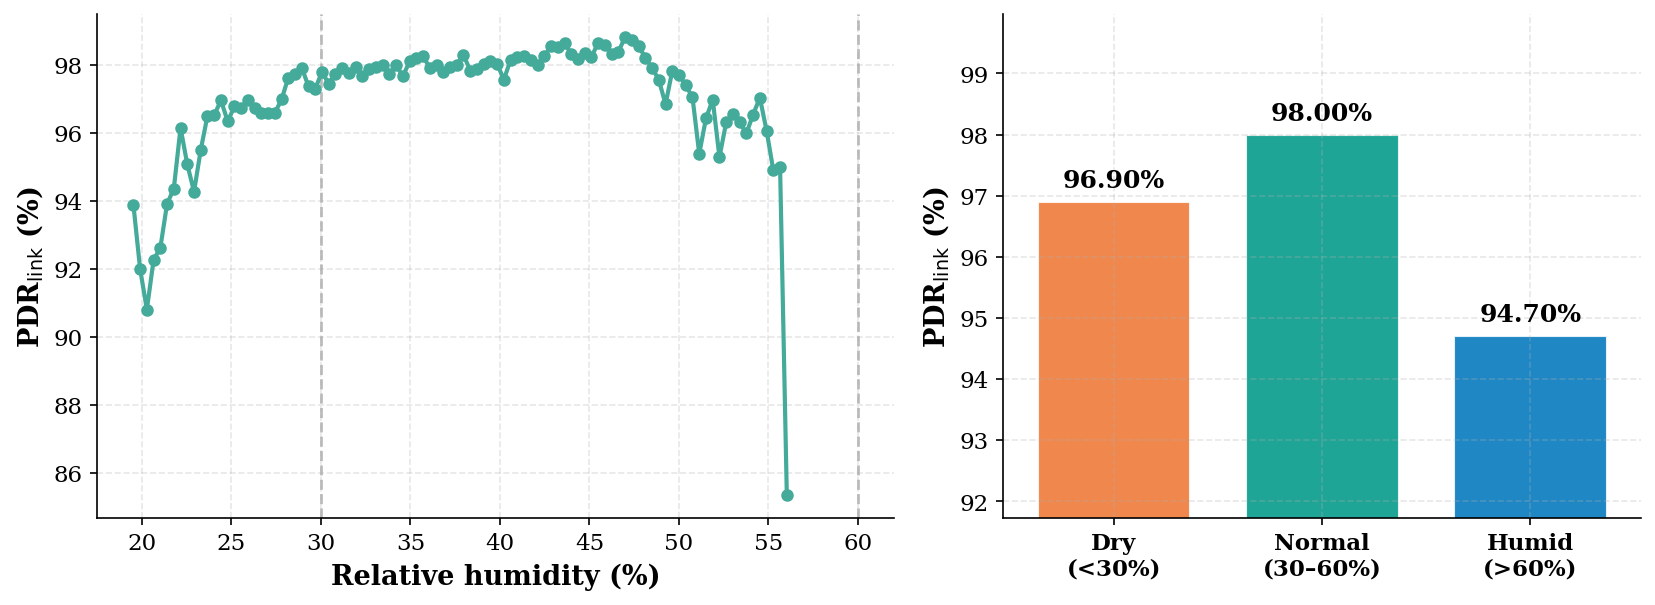

In [15]:
# Fig 05-03-f — Humidity Tier PDR (E6)
ht      = ['dry', 'normal', 'humid']
ht_labs = ['Dry\n(<30%)', 'Normal\n(30\u201360%)', 'Humid\n(>60%)']
ht_pdrs = [pdr_grp(df_link[df_link['e6_humidity_tier'] == t]) for t in ht]

fig, axL, axR = event_panels()
pdr_profile(axL, df_link, 'humidity', boundaries=[30, 60],
            xlabel='Relative humidity (%)', color=C['teal'])
tier_bars(axR, ht_pdrs, ht_labs, [C['orange'], C['green'], C['blue']])

fig.tight_layout()
save_fig(fig, '05_03_f_humidity_pdr')


## 8 · Spreading Factor Event  *(§7.6 — RQ2)*

**Hypothesis:** Higher SF → longer ToA → wider collision window → lower PDR.

Event: E7 (spreading factor)

In [16]:
print('=' * 60)
print('SPREADING FACTOR EVENT (E7)')
print('=' * 60)

TOA_MS = {7: 71.9, 8: 133.6, 9: 246.8, 10: 452.6, 11: 987.1, 12: 1810.4}
sf_pdrs = {}
sf_results = {}

print('\nE7: PDR by Spreading Factor')
for sf in [7, 8, 9, 10, 11, 12]:
    g = df_link[df_link['e7_sf'] == sf]
    rx = len(g)
    lost = int(g['tx_loss'].sum())
    pdr = rx / (rx + lost) * 100
    sf_pdrs[sf] = pdr
    print(f'    SF{sf:2d} (ToA={TOA_MS[sf]:7.1f}ms): {pdr:.2f}%  (n={rx:,})')

print(f'\n    PDR drop SF7→SF12: {sf_pdrs[7] - sf_pdrs[12]:.2f} pp')

print('\nE7: SF12 vs SF7 (key comparison)')
r = pdr_compare(df_link, 'e7_sf', 12, 7)
print_comparison(r, 'SF12 vs SF7')
sf_results['E7_sf12_vs_sf7'] = r

SPREADING FACTOR EVENT (E7)

E7: PDR by Spreading Factor
    SF 7 (ToA=   71.9ms): 98.65%  (n=536,935)
    SF 8 (ToA=  133.6ms): 98.45%  (n=534,465)
    SF 9 (ToA=  246.8ms): 97.76%  (n=518,646)
    SF10 (ToA=  452.6ms): 97.68%  (n=500,752)
    SF11 (ToA=  987.1ms): 96.38%  (n=269,154)
    SF12 (ToA= 1810.4ms): 96.91%  (n=274,502)

    PDR drop SF7→SF12: 1.74 pp

E7: SF12 vs SF7 (key comparison)
  SF12 vs SF7
                      12: 96.91%  (n=274,502)
                       7: 98.65%  (n=536,935)
    Difference        : -1.74 pp
    95% block CI      : [-2.07, -1.41] pp
    Inference         : lower PDR  ✓ statistically supported
    Bootstrap design  : 10,000 resamples of 350 x 1-day blocks



  Saved: figures/3/05_03_g_sf_pdr


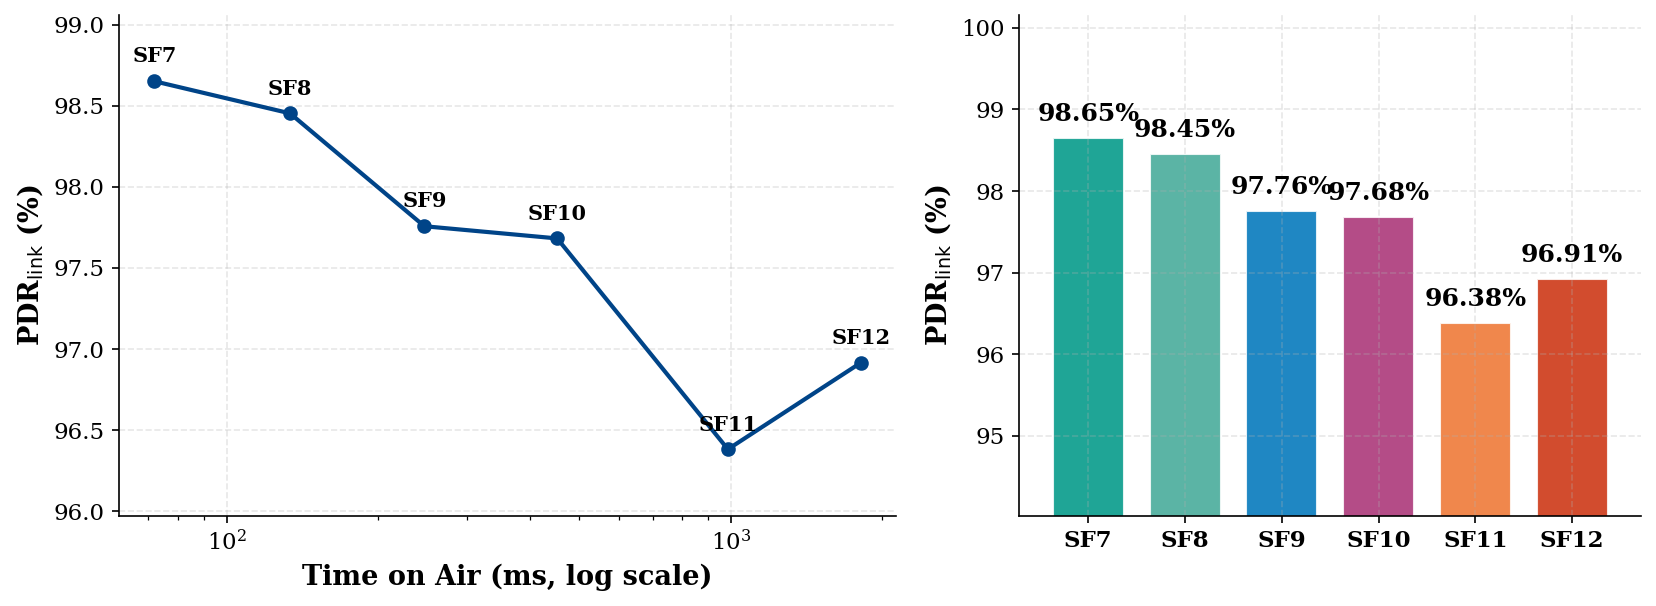

In [17]:
# Fig 05-03-g — PDR by Spreading Factor (E7)
sfs      = [7, 8, 9, 10, 11, 12]
sf_labs  = [f'SF{s}' for s in sfs]
sf_pdrs  = [pdr_grp(df_link[df_link['e7_sf'] == s]) for s in sfs]
sf_toa   = [TOA_MS[s] for s in sfs]
sf_colors = [C['green'], C['teal'], C['blue'], C['purple'], C['orange'], C['red']]

# left panel uses Time on Air, the mechanism behind the spreading-factor effect
fig, axL, axR = event_panels()
axL.plot(sf_toa, sf_pdrs, 'o-', color=C['navy'], lw=2, ms=6, zorder=3)
for t, p, l in zip(sf_toa, sf_pdrs, sf_labs):
    axL.annotate(l, (t, p), textcoords='offset points', xytext=(0, 9),
                 ha='center', fontsize=10, fontweight='bold')
axL.set_xscale('log')
axL.set_xlabel('Time on Air (ms, log scale)', fontsize=13, fontweight='bold')
axL.set_ylabel(PDR_LABEL, fontsize=13, fontweight='bold')
axL.tick_params(labelsize=11)
axL.margins(y=0.18)
tier_bars(axR, sf_pdrs, sf_labs, sf_colors, fontsize=11)

fig.tight_layout()
save_fig(fig, '05_03_g_sf_pdr')
#TODO INCREASE THE NO. OF SAMPLES? OR WHAT AM I SEEING?


## 9 · ESP Event  *(§7.5 — RQ2)*

**Hypothesis:** Weaker signal → higher loss rate.

E8 (ESP, effective signal power) uses the ThingPark six-tier classification
of the last received packet as a proxy for channel state. A flat PDR across
ESP tiers would indicate that signal quality is not the dominant loss driver.

Event: E8 (ESP tier)

In [18]:
print('=' * 60)
print('SIGNAL CONTEXT EVENT (E8)')
print('=' * 60)

signal_results = {}

# E8: ESP tier — 3 analytical tiers
print('E8: PDR by ESP Tier (poor / moderate / strong)')
for tier in ['poor', 'moderate', 'strong']:
    g = df_link[df_link['e8_esp_tier'] == tier]
    if len(g) > 0:
        rx = len(g)
        lost = int(g['tx_loss'].sum())
        pdr = rx / (rx + lost) * 100
        print(f'    {tier:<12}: {pdr:.2f}%  (n={rx:,})')

r = pdr_compare(df_link, 'e8_esp_tier', 'poor', 'strong')
print()
print_comparison(r, 'Poor ESP vs Strong ESP')
signal_results['E8_poor_vs_strong'] = r

SIGNAL CONTEXT EVENT (E8)
E8: PDR by ESP Tier (poor / moderate / strong)
    poor        : 96.63%  (n=98,423)
    moderate    : 97.12%  (n=247,848)
    strong      : 97.96%  (n=2,288,183)

  Poor ESP vs Strong ESP
                    poor: 96.63%  (n=98,423)
                  strong: 97.96%  (n=2,288,183)
    Difference        : -1.33 pp
    95% block CI      : [-1.61, -1.06] pp
    Inference         : lower PDR  ✓ statistically supported
    Bootstrap design  : 10,000 resamples of 350 x 1-day blocks



  Saved: figures/3/05_03_h_signal_context_pdr


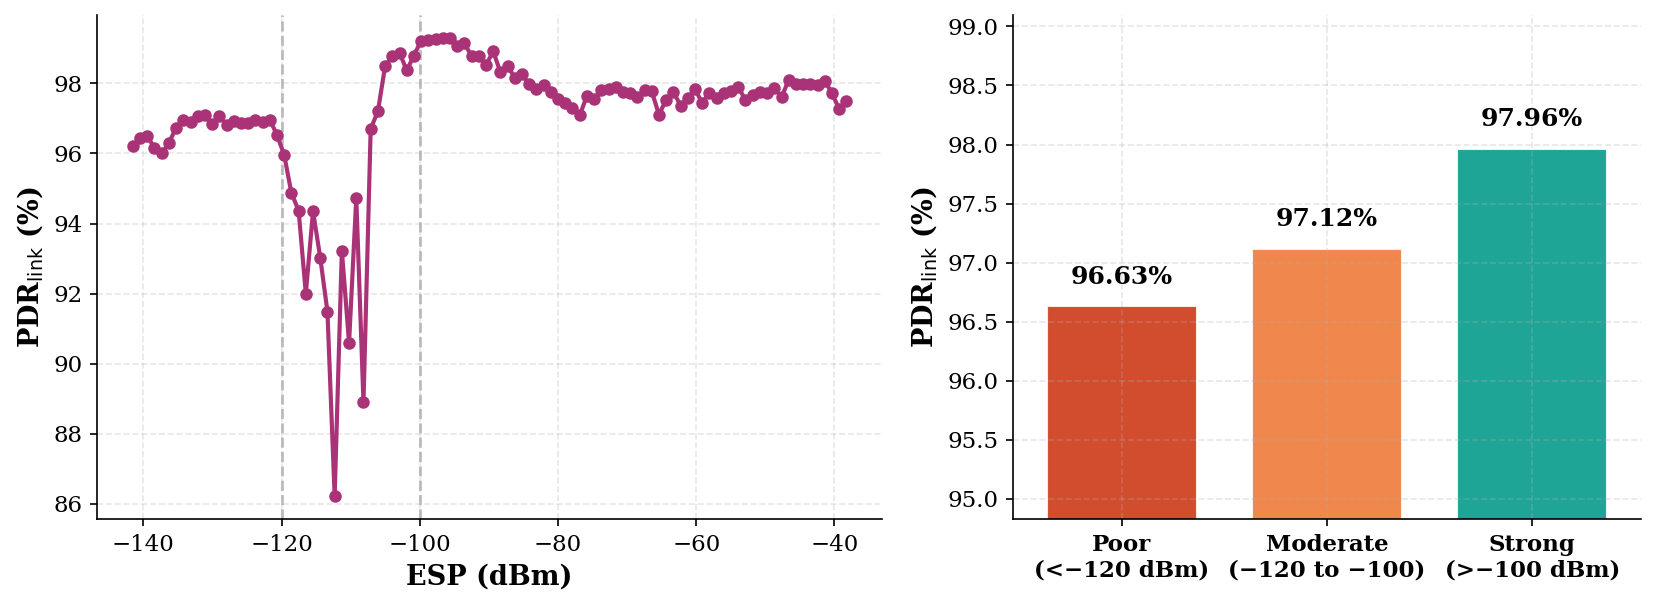

In [19]:
# Fig 05-03-h — ESP Tier PDR (E8)
et      = ['poor', 'moderate', 'strong']
et_labs = ['Poor\n(<\u2212120 dBm)', 'Moderate\n(\u2212130 to \u2212100)', 'Strong\n(>\u2212100 dBm)']
et_pdrs = [pdr_grp(df_link[df_link['e8_esp_tier'] == t]) for t in et]

fig, axL, axR = event_panels()
pdr_profile(axL, df_link, 'esp', boundaries=[-130, -100],
            xlabel='ESP (dBm)', color=C['purple'])
tier_bars(axR, et_pdrs, et_labs, [C['red'], C['orange'], C['green']])

fig.tight_layout()
save_fig(fig, '05_03_h_signal_context_pdr')


## 10 · Complete Event Summary Table  *(Tables 7.x)*

All 8 events with observed ΔPDR and its 95% block-bootstrap confidence interval — maps directly to thesis Chapter 7 tables.

In [20]:
print('=' * 60)
print('ALL EVENTS — PDR SUMMARY (E1–E8, block-bootstrap 95% CI)')
print('=' * 60)

all_results = []

binary_events = [
    ('E2', 'e2_co2_rising', 1, 0, 'ΔCO₂ transition vs stable'),
    ('E3', 'e3_office_hours', 1, 0, 'Office hours vs off-peak'),
]
cat_events = [
    ('E1', 'e1_co2_tier', 'high', 'background', 'High CO2 vs Background'),
    ('E4', 'e4_pm25_tier', 'elevated', 'clean', 'Elevated vs Clean PM2.5'),
    ('E5', 'e5_temp_tier', 'warm', 'cool', 'Warm vs Cool'),
    ('E6', 'e6_humidity_tier', 'humid', 'dry', 'Humid vs Dry'),
    ('E7', 'e7_sf', 12, 7, 'SF12 vs SF7'),
    ('E8', 'e8_esp_tier', 'poor', 'strong', 'Poor vs Strong ESP'),
]

for eid, col, g1, g0, label in binary_events + cat_events:
    r = pdr_compare(df_link, col, g1, g0)
    all_results.append(
        {
            'Event': eid,
            'Comparison': label,
            'PDR_active': r['pdr1'],
            'PDR_inactive': r['pdr0'],
            'Diff_pp': r['diff_pp'],
            'CI_low_pp': r['ci_low_pp'],
            'CI_high_pp': r['ci_high_pp'],
            'Supported': r['statistically_supported'],
        }
    )

results_df = pd.DataFrame(all_results).sort_values('Diff_pp')
plot_df = results_df.copy()

print(
    f"{'Event':<6} {'Comparison':<35} {'PDR_active':>11} {'PDR_inactive':>13} "
    f"{'Diff(pp)':>10} {'95% CI (pp)':>20} {'Supported':>10}"
)
print('-' * 112)
for _, row in results_df.iterrows():
    ci = f"[{row['CI_low_pp']:+.2f}, {row['CI_high_pp']:+.2f}]"
    sup = '✓' if row['Supported'] else '✗'
    print(
        f"{row['Event']:<6} {row['Comparison']:<35} {row['PDR_active']:>10.2f}% "
        f"{row['PDR_inactive']:>12.2f}% {row['Diff_pp']:>+9.2f} "
        f"{ci:>20} {sup:>10}"
    )

ALL EVENTS — PDR SUMMARY (E1–E8, block-bootstrap 95% CI)
Event  Comparison                           PDR_active  PDR_inactive   Diff(pp)          95% CI (pp)  Supported
----------------------------------------------------------------------------------------------------------------
E4     Elevated vs Clean PM2.5                  78.09%        98.10%    -20.01     [-27.90, -15.25]          ✓
E1     High CO2 vs Background                   95.07%        98.32%     -3.25       [-3.90, -2.62]          ✓
E6     Humid vs Dry                             94.70%        96.90%     -2.20       [-5.01, +3.33]          ✗
E7     SF12 vs SF7                              96.91%        98.65%     -1.74       [-2.07, -1.41]          ✓
E8     Poor vs Strong ESP                       96.63%        97.96%     -1.33       [-1.61, -1.06]          ✓
E3     Office hours vs off-peak                 97.03%        98.17%     -1.13       [-1.44, -0.84]          ✓
E2     ΔCO₂ transition vs stable                97.7

## 10b · Block-Length Sensitivity Check

In [21]:
# ── Bootstrapping lock-length sensitivity check (7-day blocks vs 1-day primary) ──────────
print('=' * 70)
print('BLOCK-LENGTH SENSITIVITY  —  1-day (primary) vs 7-day (robustness)')
print('=' * 70)
print(f'{"Event":<6} {"Diff 1d":>9} {"Supp 1d":>8} {"Diff 7d":>9} {"Supp 7d":>8} {"Robust":>8}')
print('-' * 52)

_robust = []
for eid, col, g1, g0, label in binary_events + cat_events:
    r1 = pdr_compare(df_link, col, g1, g0, block_days=1)
    r7 = pdr_compare(df_link, col, g1, g0, block_days=7)
    same_dir = (r1['diff_pp'] >= 0) == (r7['diff_pp'] >= 0)
    same_sup = r1['statistically_supported'] == r7['statistically_supported']
    ok = same_dir and same_sup
    _robust.append(ok)
    print(f'{eid:<6} {r1["diff_pp"]:>+8.2f} '
          f'{"yes" if r1["statistically_supported"] else "no":>8} '
          f'{r7["diff_pp"]:>+8.2f} '
          f'{"yes" if r7["statistically_supported"] else "no":>8} '
          f'{"OK" if ok else "FLAG":>8}')

print(f'\nRobust to block length: {sum(_robust)} / {len(_robust)} contrasts')


BLOCK-LENGTH SENSITIVITY  —  1-day (primary) vs 7-day (robustness)
Event    Diff 1d  Supp 1d   Diff 7d  Supp 7d   Robust
----------------------------------------------------
E2        -0.08       no    -0.08       no       OK
E3        -1.13      yes    -1.13      yes       OK
E1        -3.25      yes    -3.25      yes       OK
E4       -20.01      yes   -20.01      yes       OK
E5        +0.91      yes    +0.91      yes       OK
E6        -2.20       no    -2.20       no       OK
E7        -1.74      yes    -1.74      yes       OK
E8        -1.33      yes    -1.33      yes       OK

Robust to block length: 8 / 8 contrasts


  Saved: figures/3/05_03_i1_pdr_difference_per_event


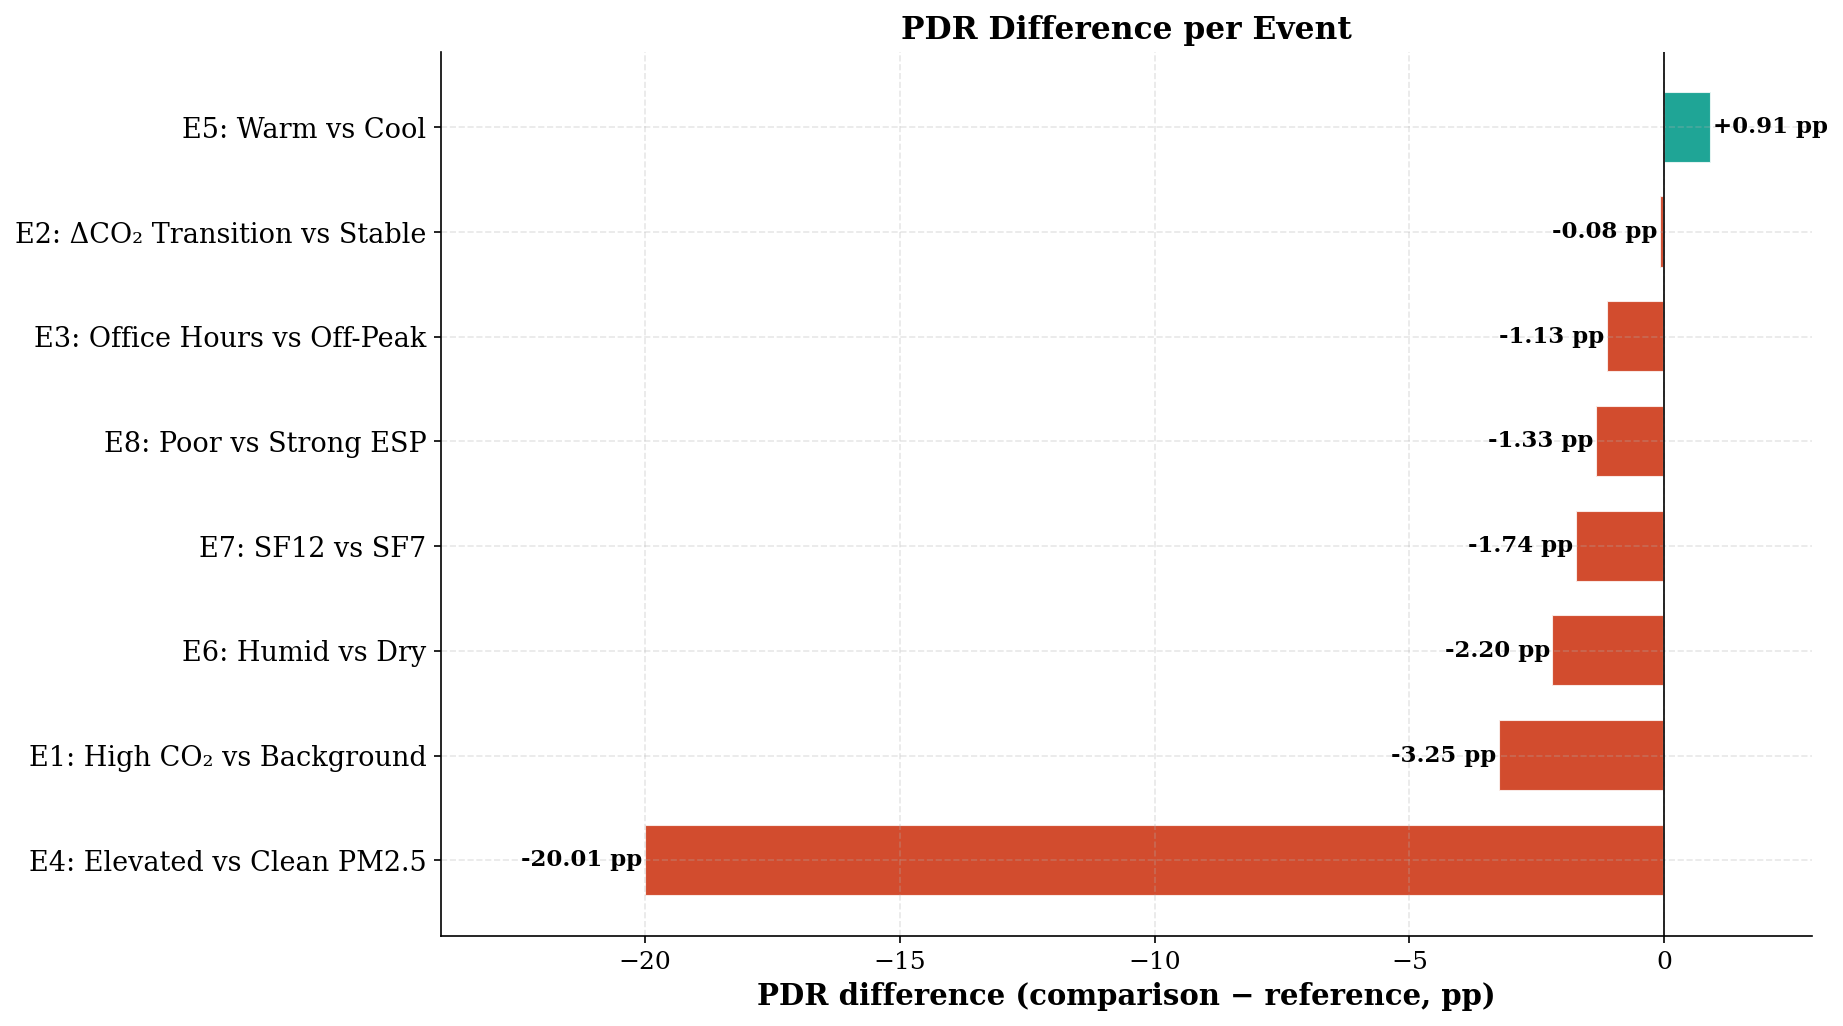

In [22]:
# Fig 03-H1 -- PDR Difference per Event

plot_df = plot_df.sort_values('Diff_pp').reset_index(drop=True)

event_labels = {
    'E1': 'E1: High CO₂ vs Background',
    'E2': 'E2: ΔCO₂ Transition vs Stable',
    'E3': 'E3: Office Hours vs Off-Peak',
    'E4': 'E4: Elevated vs Clean PM2.5',
    'E5': 'E5: Warm vs Cool',
    'E6': 'E6: Humid vs Dry',
    'E7': 'E7: SF12 vs SF7',
    'E8': 'E8: Poor vs Strong ESP',
}

plot_df['label'] = plot_df['Event'].map(event_labels)

fig1, ax1 = plt.subplots(figsize=(13, 7))

colors = [C['red'] if value < 0 else C['green'] for value in plot_df['Diff_pp']]

bars = ax1.barh(
    plot_df['label'],
    plot_df['Diff_pp'],
    color=colors,
    alpha=0.88,
    edgecolor='white',
    height=0.68,
)

ax1.axvline(x=0, color='black', linewidth=0.8, linestyle='-')

for bar, value in zip(bars, plot_df['Diff_pp']):
    ax1.text(
        value + (0.05 if value >= 0 else -0.05),
        bar.get_y() + bar.get_height() / 2,
        f'{value:+.2f} pp',
        ha='left' if value >= 0 else 'right',
        va='center',
        fontsize=11,
        fontweight='bold',
    )

ax1.tick_params(axis='y', labelsize=13)

ax1.set_xlim(plot_df['Diff_pp'].min() - 4, plot_df['Diff_pp'].max() + 2)

ax1.set_xlabel(
    'PDR difference (comparison \u2212 reference, pp)', fontsize=14, fontweight='bold'
)

ax1.set_title('PDR Difference per Event', fontsize=15, fontweight='bold')

fig1.tight_layout()
fig1.subplots_adjust(left=0.28)

save_fig(fig1, '05_03_i1_pdr_difference_per_event')

plt.show()

  Saved: figures/3/05_03_i2_event_block_bootstrap_confidence_intervals


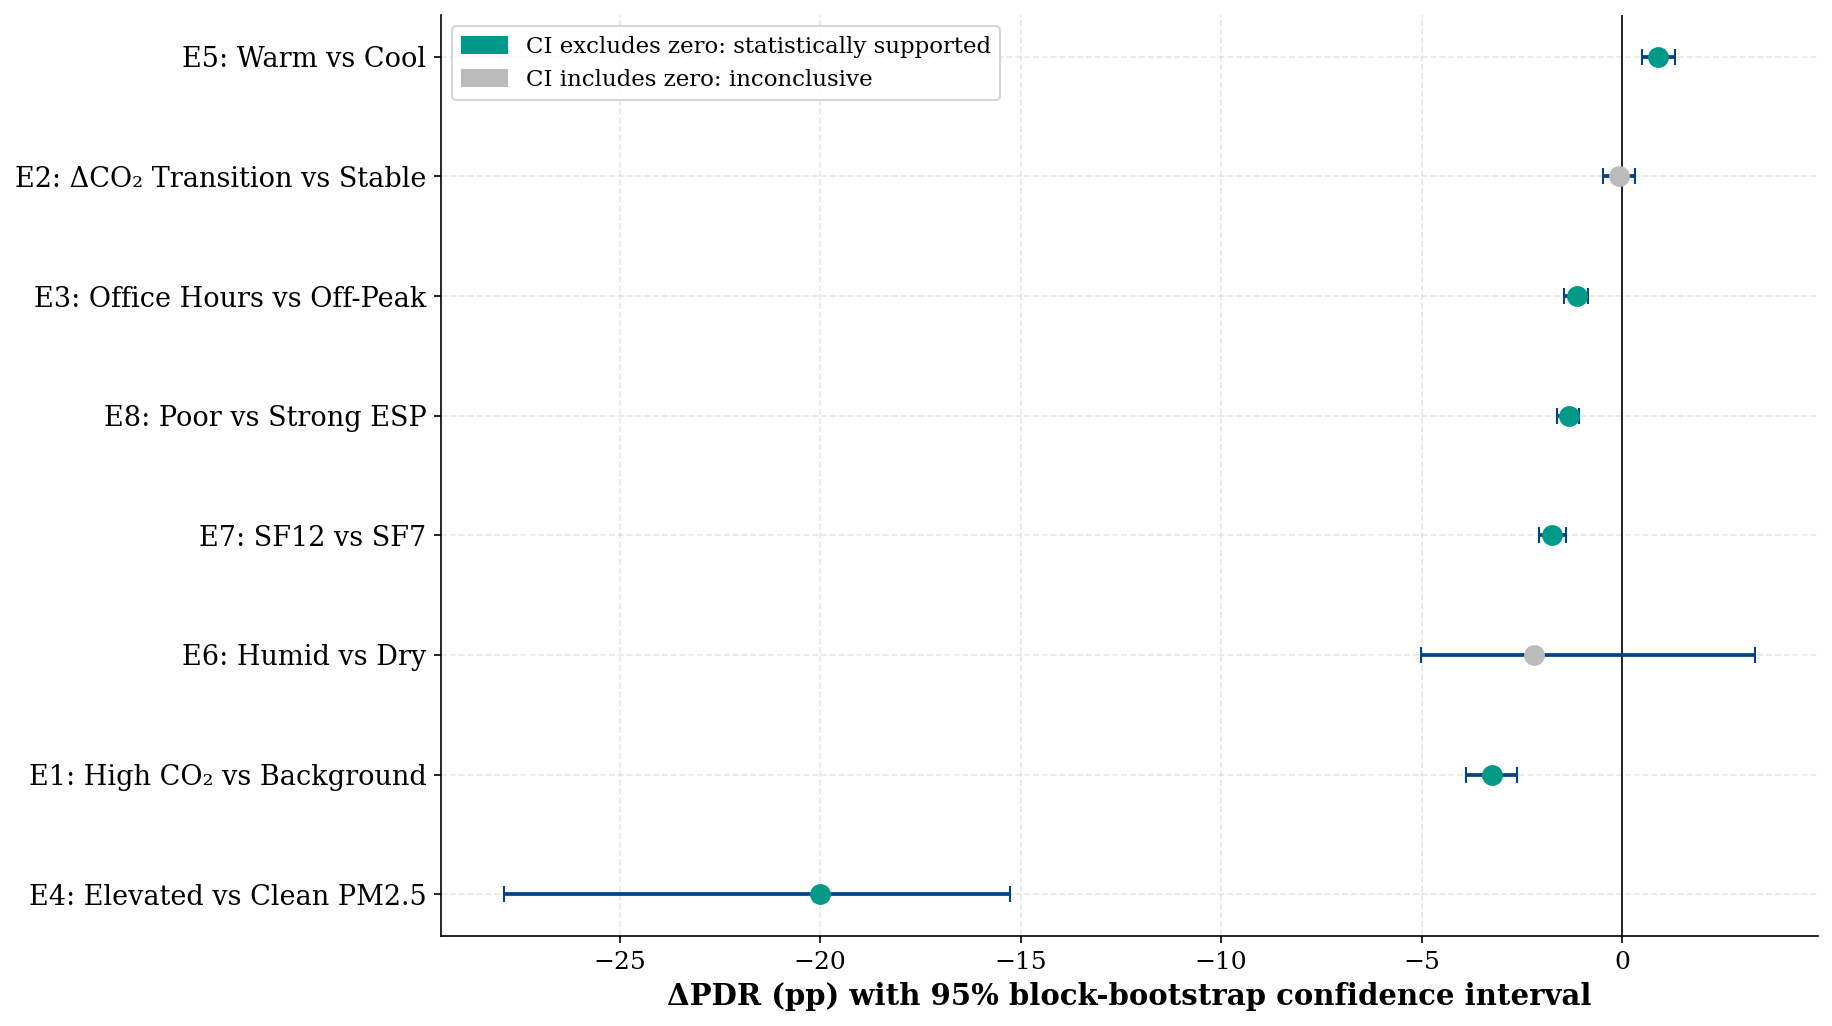

In [23]:
# Fig 03-H2 -- Block-Bootstrap Confidence Intervals per Event

fig2, ax2 = plt.subplots(figsize=(13, 7))

y_pos = np.arange(len(plot_df))

err_low = (plot_df['Diff_pp'] - plot_df['CI_low_pp']).clip(lower=0)

err_high = (plot_df['CI_high_pp'] - plot_df['Diff_pp']).clip(lower=0)

point_colors = [C['green'] if supported else C['grey'] for supported in plot_df['Supported']]

ax2.errorbar(
    plot_df['Diff_pp'],
    y_pos,
    xerr=[err_low, err_high],
    fmt='none',
    capsize=4,
    elinewidth=1.8,
    ecolor=C['navy'],
    zorder=3,
)

for y_value, delta, point_color in zip(y_pos, plot_df['Diff_pp'], point_colors):
    ax2.plot(
        delta, y_value, marker='o', markersize=9, color=point_color, linestyle='none', zorder=5
    )

ax2.axvline(x=0, color='black', linewidth=0.8, linestyle='-')

ax2.set_yticks(y_pos)

ax2.set_yticklabels(plot_df['label'], fontsize=13)

ax2.set_xlabel(
    '\u0394PDR (pp) with 95% block-bootstrap confidence interval',
    fontsize=14,
    fontweight='bold',
)

# ax2.set_title('Block-Bootstrap Confidence Intervals per Event', fontsize=15, fontweight='bold')

legend_elements = [
    mpatches.Patch(color=C['green'], label='CI excludes zero: statistically supported'),
    mpatches.Patch(color=C['grey'], label='CI includes zero: inconclusive'),
]

ax2.legend(handles=legend_elements, fontsize=11, loc='best')

fig2.tight_layout()
fig2.subplots_adjust(left=0.28)

save_fig(fig2, '05_03_i2_event_block_bootstrap_confidence_intervals')

plt.show()

## 11 · Logistic Regression — Loss Risk Model  *(§7.7 — RQ3)*

**RQ3:** Which conditions are most strongly associated with loss risk?

Binary outcome: `y = 1[tx_loss > 0]`
Predictors: all 8 events + device-ID fixed effects (ED0 as reference).
**OR > 1** → increased loss probability. 95% CI from bootstrap.

Change `N_BOOT = 10` for testing, `N_BOOT = 100` for final thesis run.


In [24]:
from sklearn.linear_model import LogisticRegression

df_link = df_link.copy()
df_link['time'] = pd.to_datetime(df_link['time'])
df_link['loss_occurred'] = (df_link['tx_loss'] > 0).astype(int)

feature_df = pd.get_dummies(
    df_link[
        [
            'e1_co2_tier',
            'e2_co2_rising',
            'e3_office_hours',
            'e4_pm25_tier',
            'e5_temp_tier',
            'e6_humidity_tier',
            'e7_sf',
            'e8_esp_tier',
            'device_id',
        ]
    ],
    drop_first=True,
).astype(float)

X = feature_df.to_numpy(dtype=float)
feat_names = feature_df.columns.tolist()
y = df_link['loss_occurred'].to_numpy(dtype=int)

# Use the same one-day block definition as the PDR bootstrap
campaign_start = df_link['time'].min().floor('D')

lr_block_id = (
    ((df_link['time'] - campaign_start).dt.total_seconds() // (24 * 60 * 60))
    .astype(int)
    .to_numpy()
)

# todo  Use 25–50 while testing and at least 1,000 for the final run
N_BOOT = 50
# N_BOOT = 1000
RANDOM_STATE = 42


def _new_lr():
    return LogisticRegression(max_iter=1000, solver='lbfgs', C=1.0)


def fit_lr_block_bootstrap(X, y, groups, feat_names, n_boot=N_BOOT, random_state=RANDOM_STATE):
    if np.unique(y).size != 2:
        raise ValueError('The outcome must contain both classes.')

    # Full-data coefficient estimates
    model = _new_lr()
    model.fit(X, y)

    coefs = model.coef_[0]
    odds_ratios = np.exp(coefs)

    # Map every row to its observed daily block
    _, group_inverse = np.unique(groups, return_inverse=True)

    n_blocks = group_inverse.max() + 1
    rng = np.random.default_rng(random_state)

    boot_coefs = []

    for b in range(n_boot):
        # Sample complete daily blocks with replacement
        sampled_blocks = rng.integers(0, n_blocks, size=n_blocks)

        block_multiplicity = np.bincount(sampled_blocks, minlength=n_blocks)

        # Every row from a selected day receives the
        # multiplicity assigned to that day
        row_weights = block_multiplicity[group_inverse].astype(float)

        keep = row_weights > 0

        # Skip a replicate only when one outcome class is absent
        if np.unique(y[keep]).size != 2:
            continue

        weights = row_weights[keep]

        # Keep the total sample weight comparable across replicates
        weights *= len(y) / weights.sum()

        boot_model = _new_lr()

        boot_model.fit(X[keep], y[keep], sample_weight=weights)

        boot_coefs.append(boot_model.coef_[0])

        if (b + 1) % 100 == 0 or (b + 1) == n_boot:
            print(f'  Completed {b + 1:,} of ' f'{n_boot:,} block resamples')

    boot_coefs = np.asarray(boot_coefs, dtype=float)

    minimum_valid = int(np.ceil(0.9 * n_boot))

    if len(boot_coefs) < minimum_valid:
        raise RuntimeError(
            f'Only {len(boot_coefs):,} of '
            f'{n_boot:,} bootstrap fits were valid. '
            f'At least {minimum_valid:,} were required.'
        )

    ci_lo = np.exp(np.percentile(boot_coefs, 2.5, axis=0))

    ci_hi = np.exp(np.percentile(boot_coefs, 97.5, axis=0))

    ci_df = pd.DataFrame({'OR': odds_ratios, 'CI_lo': ci_lo, 'CI_hi': ci_hi}, index=feat_names)

    ci_df['Supported'] = (ci_df['CI_lo'] > 1.0) | (ci_df['CI_hi'] < 1.0)

    result = ci_df['OR'].sort_values(ascending=False)

    return result, ci_df


print(f'Fitting loss occurrence model with ' f'{N_BOOT:,} one-day block resamples')

print(f'Features {len(feat_names)}')

odds_ratios, ci_loss = fit_lr_block_bootstrap(X, y, lr_block_id, feat_names)

print(f'\n{"Predictor":<40} ' f'{"OR":>8} ' f'{"95% CI":>22} ' f'{"Inference":>24}')

print('-' * 98)
print('\nEVENT PREDICTORS')

for feat, OR in odds_ratios.items():
    if feat.startswith('device_id'):
        continue

    lo = ci_loss.loc[feat, 'CI_lo']
    hi = ci_loss.loc[feat, 'CI_hi']

    if lo > 1.0:
        inference = 'higher adjusted odds'
    elif hi < 1.0:
        inference = 'lower adjusted odds'
    else:
        inference = 'inconclusive'

    print(f'{feat:<40} ' f'{OR:>8.4f} ' f'[{lo:.3f}, {hi:.3f}] ' f'{inference:>24}')

print('\nDEVICE-LOCATION CONTROL TERMS ' 'RELATIVE TO ED0')

for feat, OR in odds_ratios.items():
    if not feat.startswith('device_id'):
        continue

    lo = ci_loss.loc[feat, 'CI_lo']
    hi = ci_loss.loc[feat, 'CI_hi']

    if lo > 1.0:
        inference = 'higher adjusted odds'
    elif hi < 1.0:
        inference = 'lower adjusted odds'
    else:
        inference = 'inconclusive'

    print(f'{feat:<40} ' f'{OR:>8.4f} ' f'[{lo:.3f}, {hi:.3f}] ' f'{inference:>24}')

Fitting loss occurrence model with 50 one-day block resamples
Features 18
  Completed 50 of 50 block resamples

Predictor                                      OR                 95% CI                Inference
--------------------------------------------------------------------------------------------------

EVENT PREDICTORS
e4_pm25_tier_elevated                      9.1822 [1.584, 13.240]     higher adjusted odds
e4_pm25_tier_moderate                      2.6810 [2.263, 2.958]     higher adjusted odds
e1_co2_tier_high                           2.4076 [2.143, 2.735]     higher adjusted odds
e3_office_hours                            1.3153 [1.240, 1.383]     higher adjusted odds
e7_sf                                      1.2349 [1.208, 1.271]     higher adjusted odds
e1_co2_tier_moderate                       1.2004 [1.066, 1.274]     higher adjusted odds
e8_esp_tier_poor                           1.0071 [0.865, 1.072]             inconclusive
e2_co2_rising                             

  Saved: figures/3/05_03_j_loss_risk_forest


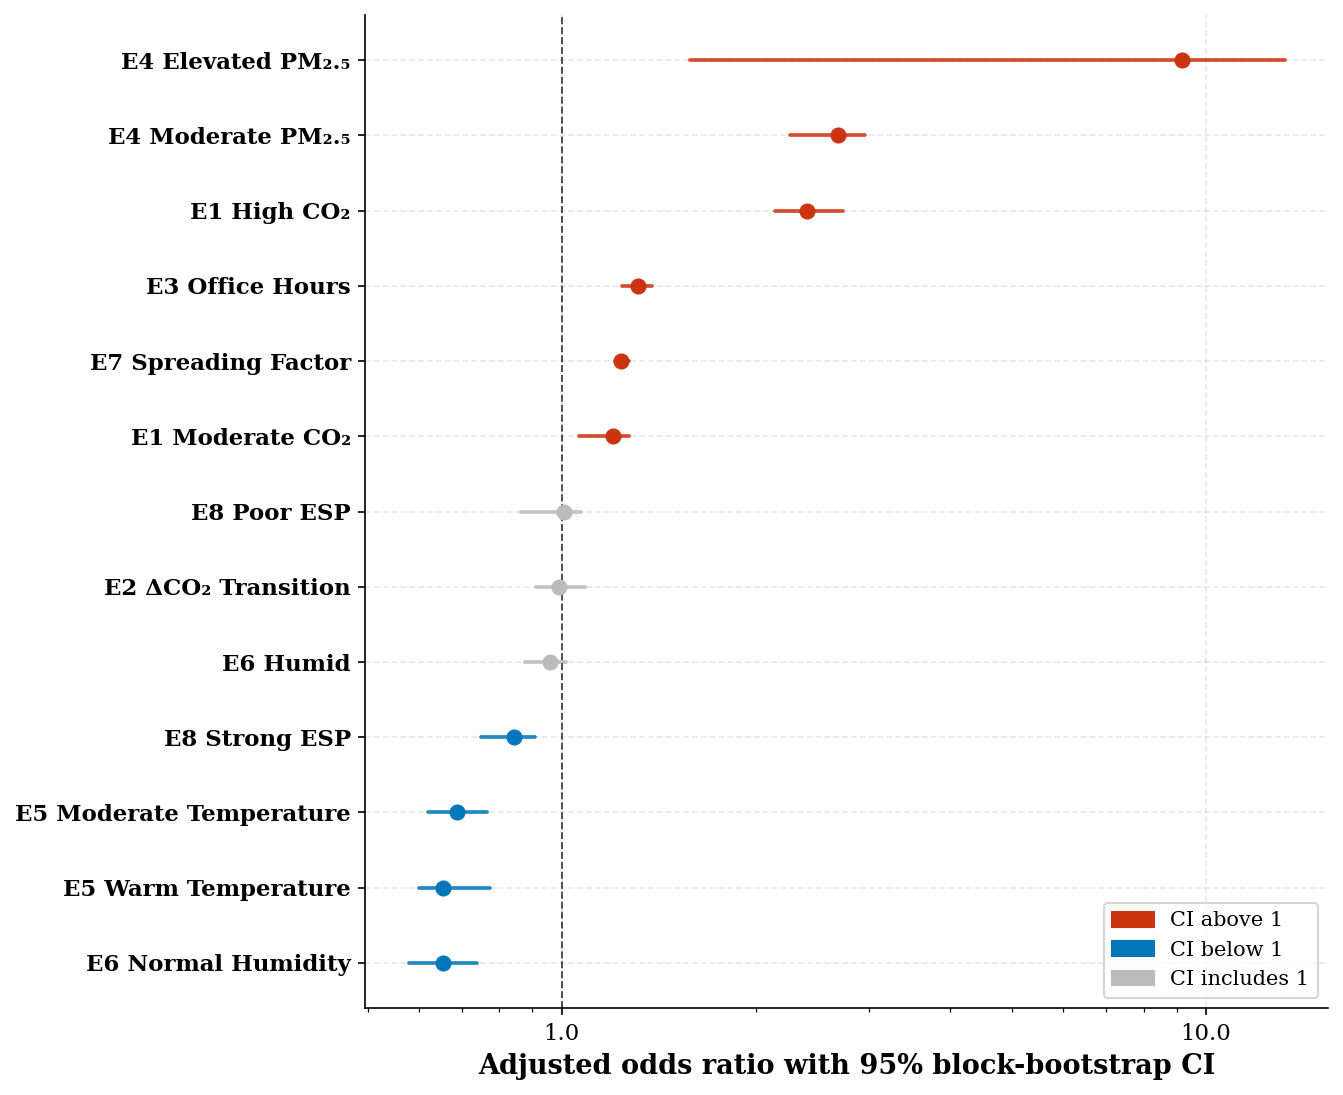

In [25]:
# Fig 03-I — Loss Occurrence Odds-Ratio Forest Plot

plot_labels = {
    'e1_co2_tier_high': 'E1 High CO₂',
    'e1_co2_tier_moderate': 'E1 Moderate CO₂',
    'e2_co2_rising': 'E2 ΔCO₂ Transition',
    'e3_office_hours': 'E3 Office Hours',
    'e4_pm25_tier_elevated': 'E4 Elevated PM₂.₅',
    'e4_pm25_tier_moderate': 'E4 Moderate PM₂.₅',
    'e5_temp_tier_moderate': 'E5 Moderate Temperature',
    'e5_temp_tier_warm': 'E5 Warm Temperature',
    'e6_humidity_tier_humid': 'E6 Humid',
    'e6_humidity_tier_normal': 'E6 Normal Humidity',
    'e7_sf': 'E7 Spreading Factor',
    'e8_esp_tier_poor': 'E8 Poor ESP',
    'e8_esp_tier_strong': 'E8 Strong ESP',
}

event_index = [feat for feat in ci_loss.index if not feat.startswith('device_id')]

ev_j = ci_loss.loc[event_index, ['OR', 'CI_lo', 'CI_hi', 'Supported']].copy()

ev_j['label'] = [plot_labels.get(feat, feat) for feat in ev_j.index]

ev_j = ev_j.sort_values('OR', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, len(ev_j) * 0.42 + 2))

for i, row in ev_j.iterrows():
    if row['CI_lo'] > 1.0:
        color = C['red']
    elif row['CI_hi'] < 1.0:
        color = C['blue']
    else:
        color = C['grey']

    ax.plot(
        [row['CI_lo'], row['CI_hi']],
        [i, i],
        color=color,
        lw=1.8,
        alpha=0.85,
        solid_capstyle='round',
    )

    ax.scatter(row['OR'], i, color=color, s=45, zorder=5)

ax.axvline(x=1.0, color='black', lw=0.9, ls='--', alpha=0.7)

ax.set_yticks(range(len(ev_j)))

ax.set_yticklabels(ev_j['label'], fontsize=11, fontweight='bold')

ax.set_xlabel(
    'Adjusted odds ratio with 95% block-bootstrap CI', fontsize=13, fontweight='bold'
)

ax.set_xscale('log')
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.tick_params(axis='x', labelsize=11)

ax.legend(
    handles=[
        mpatches.Patch(color=C['red'], label='CI above 1'),
        mpatches.Patch(color=C['blue'], label='CI below 1'),
        mpatches.Patch(color=C['grey'], label='CI includes 1'),
    ],
    loc='lower right',
    fontsize=10,
)

fig.tight_layout()
fig.subplots_adjust(left=0.34)

save_fig(fig, '05_03_j_loss_risk_forest')

plt.show()

## 12 · Burst Loss Risk Model  *(§7.7 — RQ3)*

Same framework predicting burst loss: `y = 1[tx_loss >= 3]`

Burst-loss ORs are systematically larger than packet-loss ORs for the same
events — high-occupancy and high-SF conditions disproportionately increase burst severity.


In [ ]:
print('=' * 60)
print('LOGISTIC REGRESSION — BURST OCCURRENCE MODEL')
print('=' * 60)

df_link['burst_occurred'] = (df_link['tx_loss'] >= 3).astype(int)

y_burst = df_link['burst_occurred'].to_numpy(dtype=int)

print(f'Fitting burst occurrence model with ' f'{N_BOOT:,} one-day block resamples')

or_burst, ci_burst = fit_lr_block_bootstrap(X, y_burst, lr_block_id, feat_names)

print(
    f'\n{"Predictor":<40} '
    f'{"OR loss":>10} '
    f'{"95% CI loss":>22} '
    f'{"OR burst":>10} '
    f'{"95% CI burst":>22}'
)

print('-' * 110)

for feat in odds_ratios.index:
    if feat.startswith('device_id'):
        continue

    or_l = odds_ratios[feat]
    lo_l = ci_loss.loc[feat, 'CI_lo']
    hi_l = ci_loss.loc[feat, 'CI_hi']

    or_b = or_burst[feat]
    lo_b = ci_burst.loc[feat, 'CI_lo']
    hi_b = ci_burst.loc[feat, 'CI_hi']

    print(
        f'{feat:<40} '
        f'{or_l:>10.4f} '
        f'[{lo_l:.3f}, {hi_l:.3f}] '
        f'{or_b:>10.4f} '
        f'[{lo_b:.3f}, {hi_b:.3f}]'
    )

print(
    '\nDevice-location terms remain in both models '
    'as controls and are omitted from this comparison.'
)

print(
    'The two odds ratios describe different binary '
    'outcomes and are presented side by side without '
    'forming an odds-ratio ratio.'
)

LOGISTIC REGRESSION — BURST OCCURRENCE MODEL
Fitting burst occurrence model with 50 one-day block resamples


  Saved: figures/3/05_03_k_loss_vs_burst_forest


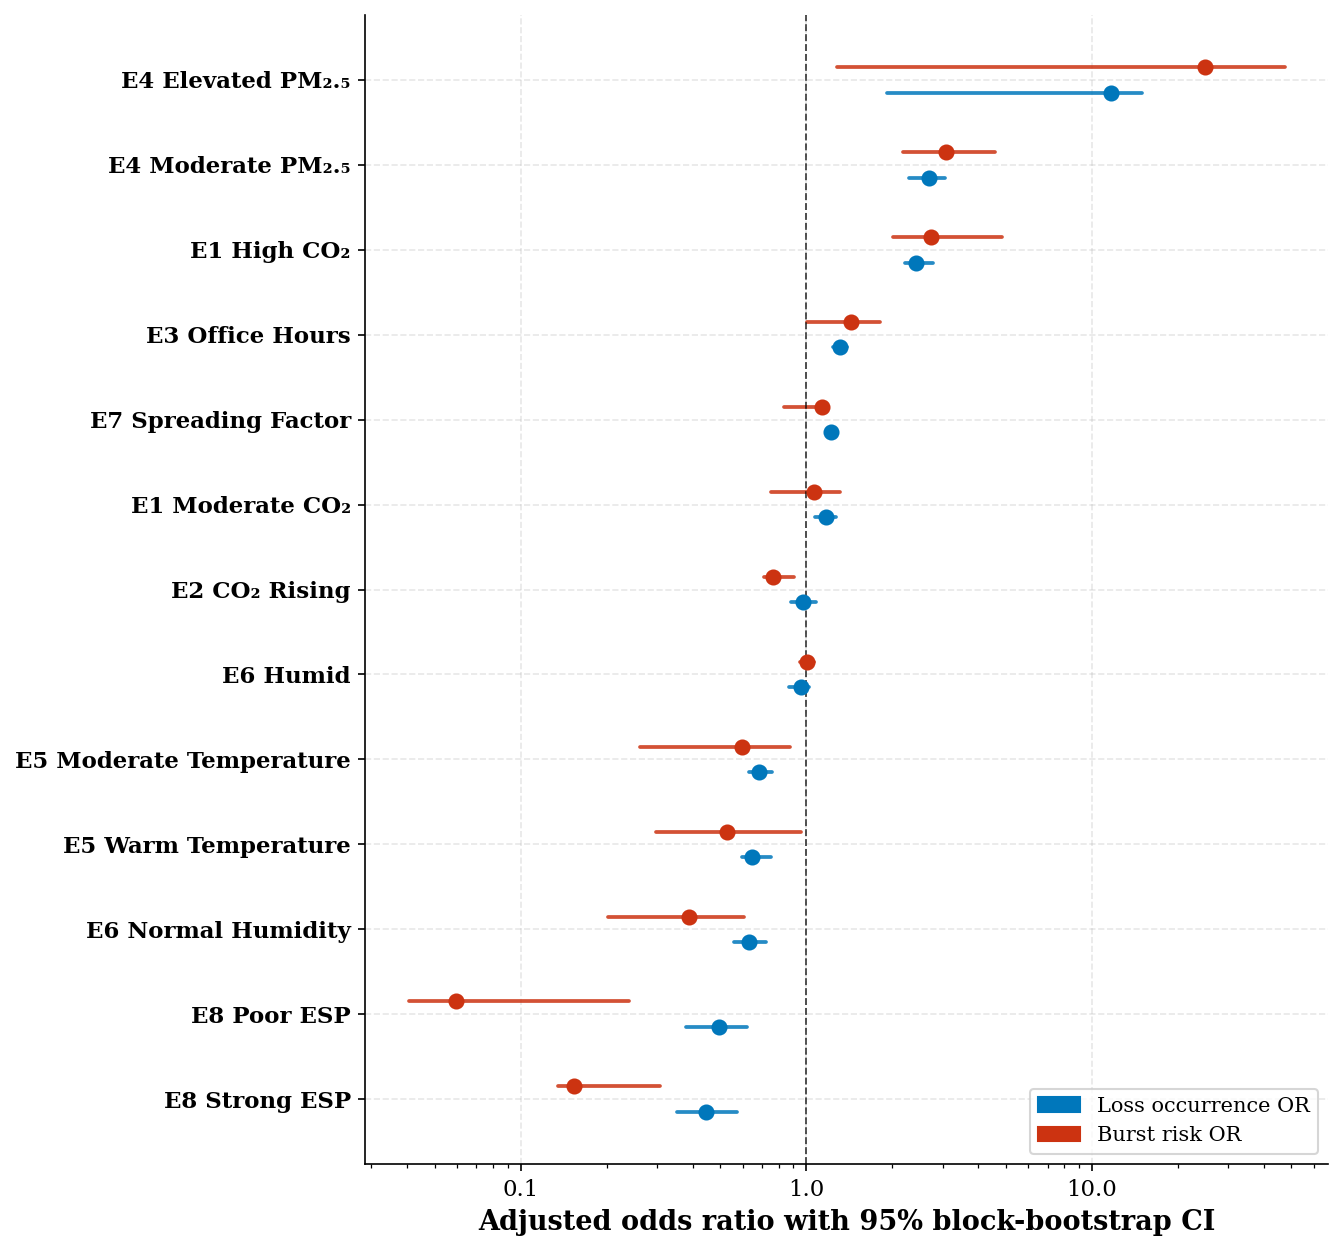

In [27]:
# Fig 03-J — Loss vs Burst Risk Odds Ratios

event_index_j = [feat for feat in ci_loss.index if not feat.startswith('device_id')]

oj = pd.DataFrame(
    {
        'OR_loss': odds_ratios.loc[event_index_j],
        'lo_loss': ci_loss.loc[event_index_j, 'CI_lo'],
        'hi_loss': ci_loss.loc[event_index_j, 'CI_hi'],
        'OR_burst': or_burst.loc[event_index_j],
        'lo_burst': ci_burst.loc[event_index_j, 'CI_lo'],
        'hi_burst': ci_burst.loc[event_index_j, 'CI_hi'],
    }
)
oj['label'] = [plot_labels.get(feat, feat) for feat in oj.index]
oj = oj.sort_values('OR_loss', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, len(oj) * 0.5 + 2))

for i, row in oj.iterrows():
    ax.plot(
        [row['lo_loss'], row['hi_loss']],
        [i - 0.15, i - 0.15],
        color=C['blue'],
        lw=1.8,
        alpha=0.85,
        solid_capstyle='round',
    )
    ax.scatter(row['OR_loss'], i - 0.15, color=C['blue'], s=45, zorder=5)

    ax.plot(
        [row['lo_burst'], row['hi_burst']],
        [i + 0.15, i + 0.15],
        color=C['red'],
        lw=1.8,
        alpha=0.85,
        solid_capstyle='round',
    )
    ax.scatter(row['OR_burst'], i + 0.15, color=C['red'], s=45, zorder=5)

ax.axvline(x=1.0, color='black', lw=0.9, ls='--', alpha=0.7)
ax.set_yticks(range(len(oj)))
ax.set_yticklabels(oj['label'], fontsize=11, fontweight='bold')
ax.set_xlabel(
    'Adjusted odds ratio with 95% block-bootstrap CI', fontsize=13, fontweight='bold'
)
ax.set_xscale('log')
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.tick_params(axis='x', labelsize=11)

ax.legend(
    handles=[
        mpatches.Patch(color=C['blue'], label='Loss occurrence OR'),
        mpatches.Patch(color=C['red'], label='Burst risk OR'),
    ],
    loc='lower right',
    fontsize=10,
)

fig.tight_layout()
fig.subplots_adjust(left=0.34)
save_fig(fig, '05_03_k_loss_vs_burst_forest')
plt.show()

## 13 · Key Findings Summary  *(§7 summary)*

Thesis-ready statements for Chapter 7.


In [28]:
print('=' * 65)
print('KEY FINDINGS SUMMARY')
print('=' * 65)

# Campaign-wide reliability metrics
lost_link = int(df_link['tx_loss'].sum())

pdr_link = len(df_link) / (len(df_link) + lost_link) * 100

total_app = int(df['fw_drop'].sum())
total_radio = int(df['tx_loss'].sum())

pdr_system = len(df) / (len(df) + total_app + total_radio) * 100

pdr_raw = len(df) / (len(df) + total_radio) * 100

# Per-device link-layer PDR spread
device_pdrs = df_link.groupby('device_id', observed=True).apply(
    lambda g: (len(g) / (len(g) + int(g['tx_loss'].sum())) * 100), include_groups=False
)

pdr_range = float(device_pdrs.max() - device_pdrs.min())

print(f"""
┌─ RQ1  Campaign-Wide Reliability ───────────────────────────┐
  PDR_system                  {pdr_system:>10.2f}%
  PDR_raw                     {pdr_raw:>10.2f}%
  PDR_link                    {pdr_link:>10.2f}%
  PDR range across devices    {pdr_range:>10.2f} pp
  Intervals analysed          {len(df_link):>10,}
└────────────────────────────────────────────────────────────┘
""")

print(f"""
┌─ RQ2  Event-Conditioned PDR ───────────────────────────────────────────────────┐
  Top findings ranked by absolute PDR difference

  {'Event':<8} {'Comparison':<38} {'Diff pp':>10} {'95% CI pp':>22} {'Supported':>12}
  {'-' * 94}""")

top_n = results_df.reindex(
    results_df['Diff_pp'].abs().sort_values(ascending=False).index
).head(6)

for _, row in top_n.iterrows():
    ci = f"[{row['CI_low_pp']:+.2f}, " f"{row['CI_high_pp']:+.2f}]"

    supported = 'Yes' if row['Supported'] else 'No'

    print(
        f"  {row['Event']:<8} "
        f"{row['Comparison']:<38} "
        f"{row['Diff_pp']:>+9.2f} "
        f"{ci:>22} "
        f"{supported:>12}"
    )

# Retain only predictors present in both fitted models
event_predictors = [
    feat
    for feat in odds_ratios.index
    if (not feat.startswith('device_id') and feat in or_burst.index)
]

# Rank predictors by their strongest distance from OR = 1
top_predictors = sorted(
    event_predictors,
    key=lambda feat: max(abs(np.log(odds_ratios[feat])), abs(np.log(or_burst[feat]))),
    reverse=True,
)[:5]

print(f"""
┌─ RQ3  Strongest Adjusted Associations ─────────────────────────────────────────────────────────────┐

  {'Predictor':<38} {'OR loss':>10} {'95% CI loss':>22} {'OR burst':>10} {'95% CI burst':>22}
  {'-' * 106}""")

for feat in top_predictors:
    or_l = odds_ratios[feat]
    lo_l = ci_loss.loc[feat, 'CI_lo']
    hi_l = ci_loss.loc[feat, 'CI_hi']

    or_b = or_burst[feat]
    lo_b = ci_burst.loc[feat, 'CI_lo']
    hi_b = ci_burst.loc[feat, 'CI_hi']

    print(
        f'  {feat:<38} '
        f'{or_l:>10.3f} '
        f'[{lo_l:.3f}, {hi_l:.3f}] '
        f'{or_b:>10.3f} '
        f'[{lo_b:.3f}, {hi_b:.3f}]'
    )

print("""
  Device-location indicators were included as adjustment variables
  and are omitted from this summary.
└─────────────────────────────────────────────────────────────────────────────────────────────────────┘
""")

KEY FINDINGS SUMMARY

┌─ RQ1  Campaign-Wide Reliability ───────────────────────────┐
  PDR_system                       83.77%
  PDR_raw                          91.04%
  PDR_link                         97.83%
  PDR range across devices          1.81 pp
  Intervals analysed           2,634,454
└────────────────────────────────────────────────────────────┘


┌─ RQ2  Event-Conditioned PDR ───────────────────────────────────────────────────┐
  Top findings ranked by absolute PDR difference

  Event    Comparison                                Diff pp              95% CI pp    Supported
  ----------------------------------------------------------------------------------------------
  E4       Elevated vs Clean PM2.5                   -20.01       [-27.90, -15.25]          Yes
  E1       High CO2 vs Background                     -3.25         [-3.90, -2.62]          Yes
  E6       Humid vs Dry                               -2.20         [-5.01, +3.33]           No
  E7       SF12 vs SF7  

## 14 · Save Results


In [29]:
# save complete event results table
results_df.to_csv(DATA_DIR / '3_results.csv', index=False)

# save OR table — loss + burst + 95% CI (Table 7.8)
or_table = pd.DataFrame(
    {
        'predictor': odds_ratios.index,
        'OR_loss': odds_ratios.values,
        'loss_CI_lo': [ci_loss.loc[f, 'CI_lo'] for f in odds_ratios.index],
        'loss_CI_hi': [ci_loss.loc[f, 'CI_hi'] for f in odds_ratios.index],
        'OR_burst': [or_burst[f] for f in odds_ratios.index],
        'burst_CI_lo': [ci_burst.loc[f, 'CI_lo'] for f in odds_ratios.index],
        'burst_CI_hi': [ci_burst.loc[f, 'CI_hi'] for f in odds_ratios.index],
    }
)
or_table.to_csv(DATA_DIR / '3_odds_ratios.csv', index=False)

# save concurrent same-SF exposure companion results -- not part of the
# E1-E8 taxonomy, kept in its own file rather than mixed into 3_results.csv
# e9_table = pd.DataFrame([
#     {
#         'comparison': name,
#         'group1': r['group1'], 'group0': r['group0'],
#         'pdr1': r['pdr1'], 'pdr0': r['pdr0'],
#         'diff_pp': r['diff_pp'],
#         'ci_low_pp': r['ci_low_pp'], 'ci_high_pp': r['ci_high_pp'],
#         'supported': r['statistically_supported'],
#     }
#     for name, r in e9_results.items()
# ])
# e9_table.to_csv(DATA_DIR / '3_e9_companion_results.csv', index=False)

print(f'Saved: {DATA_DIR / "3_results.csv"}')
print(f'Saved: {DATA_DIR / "3_odds_ratios.csv"}')
# print(f'Saved: {DATA_DIR / "3_e9_companion_results.csv"}')
print(f'\nNotebook 03 complete.')

Saved: ..\data\3_results.csv
Saved: ..\data\3_odds_ratios.csv

Notebook 03 complete.


## 15 · Blocked-CV AUC & Thesis Fill-In Sheet

In [30]:
# ── Blocked-CV AUC for both logistic models + thesis fill-in sheet ─────────
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
import numpy as np

def _blocked_auc(X, y, groups, n_splits=5):
    aucs = []
    for tr, te in GroupKFold(n_splits=n_splits).split(X, y, groups=groups):
        if np.unique(y[te]).size < 2:
            continue
        m = LogisticRegression(max_iter=1000, solver='lbfgs', C=1.0)
        m.fit(X[tr], y[tr])
        aucs.append(roc_auc_score(y[te], m.predict_proba(X[te])[:, 1]))
    return float(np.mean(aucs)), float(np.std(aucs))

auc_loss, auc_loss_sd = _blocked_auc(X, y, lr_block_id)
auc_burst, auc_burst_sd = _blocked_auc(X, y_burst, lr_block_id)
print(f'Loss  model — blocked 5-fold AUC: {auc_loss:.3f} +/- {auc_loss_sd:.3f}')
print(f'Burst model — blocked 5-fold AUC: {auc_burst:.3f} +/- {auc_burst_sd:.3f}')

print('\n' + '=' * 74)
print('THESIS FILL-IN SHEET — copy [RERUN] slots in chap:results')
print('=' * 74)
print(f'AUC loss model  : {auc_loss:.3f}')
print(f'AUC burst model : {auc_burst:.3f}')
print(f'Logistic N_boot : {N_BOOT:,}')
print('\nEvent predictors — OR_loss [CI] and OR_burst [CI]:')
for feat in odds_ratios.index:
    if feat.startswith('device_id'):
        continue
    print(f'  {feat:<30} '
          f'loss {odds_ratios[feat]:>8.3f} '
          f'[{ci_loss.loc[feat,"CI_lo"]:.3f}, {ci_loss.loc[feat,"CI_hi"]:.3f}]   '
          f'burst {or_burst[feat]:>8.3f} '
          f'[{ci_burst.loc[feat,"CI_lo"]:.3f}, {ci_burst.loc[feat,"CI_hi"]:.3f}]')
print('\nDevice fixed effects — OR_loss [CI]:')
for feat in odds_ratios.index:
    if feat.startswith('device_id'):
        print(f'  {feat:<30} {odds_ratios[feat]:>8.3f} '
              f'[{ci_loss.loc[feat,"CI_lo"]:.3f}, {ci_loss.loc[feat,"CI_hi"]:.3f}]')


Loss  model — blocked 5-fold AUC: 0.696 +/- 0.009
Burst model — blocked 5-fold AUC: 0.690 +/- 0.031

THESIS FILL-IN SHEET — copy [RERUN] slots in chap:results
AUC loss model  : 0.696
AUC burst model : 0.690
Logistic N_boot : 50

Event predictors — OR_loss [CI] and OR_burst [CI]:
  e4_pm25_tier_elevated          loss   11.628 [1.921, 15.003]   burst   24.962 [1.279, 47.301]
  e4_pm25_tier_moderate          loss    2.695 [2.293, 3.069]   burst    3.087 [2.186, 4.562]
  e1_co2_tier_high               loss    2.415 [2.208, 2.781]   burst    2.731 [2.013, 4.860]
  e3_office_hours                loss    1.316 [1.242, 1.393]   burst    1.432 [1.006, 1.807]
  e7_sf                          loss    1.222 [1.204, 1.260]   burst    1.133 [0.833, 1.131]
  e1_co2_tier_moderate           loss    1.176 [1.071, 1.273]   burst    1.061 [0.750, 1.316]
  e2_co2_rising                  loss    0.976 [0.888, 1.084]   burst    0.764 [0.708, 0.905]
  e6_humidity_tier_humid         loss    0.960 [0.873, 1.025